# 1. Data Preprocessing and Cleaning

In [1]:
### Import libraies
import pandas as pd # Data manipulation and analysis.
import numpy as np # Numerical operations and array handling.
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # Statistical functions and tests.
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


pd.set_option('display.max_columns', None) # Display all columns in DataFrame output.
pd.set_option('display.max_rows', None) # Display all rows in DataFrame output.


In [2]:
# Load data from CSV
df = pd.read_csv('data/intrusion_data.csv')

In [3]:
# Display csv file in table view (5 rows)
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,NaN,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [4]:
# Return number of rows and columns in the DataFrame
df.shape

(9537, 11)

In [5]:
# Return information about the DataFrame, Including data types and non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9060 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  8106 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         8583 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


The dataset has total rows of 9537 and some columns have missing values that will need to be addressed. 

There is a mix of data types and columns are numerical (int64, float64), and categorical (object).

Columns (session_duration, encryption_used, ip_reputation_score and browser_type) have non-null counts lower than the total number of entries, indicating missing values that will need to be addressed.

In [6]:
# Return summary statistics for numerical columns in the DataFrame
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
network_packet_size,9537.0,500.430639,198.379364,64.000000,365.000000,499.000000,635.000000,1285.000000
login_attempts,9537.0,4.032086,1.963012,1.000000,3.000000,4.000000,5.000000,13.000000
session_duration,9060.0,789.259572,785.282753,0.500000,229.883982,553.389511,1102.056853,7190.392213
ip_reputation_score,8106.0,0.330970,0.176582,0.002497,0.191938,0.313947,0.452014,0.891286
failed_logins,9537.0,1.517773,1.033988,0.000000,1.000000,1.000000,2.000000,5.000000
unusual_time_access,9537.0,0.149942,0.357034,0.000000,0.000000,0.000000,0.000000,1.000000
attack_detected,9537.0,0.447101,0.497220,0.000000,0.000000,0.000000,1.000000,1.000000


The summary statistics provides overview of  7 out of 11 columns of the dataset. This aligns with the 4 categorical (object) columns we saw earlier.

There is a wide variance in the session_duration which has a maximum value over 7,000. the mean (789.259572) is significantly higher than the median (50th percentile, 553.389511).

For session_duration, the mean (789) is significantly higher than the median (50th percentile, 553).

The 'attack_detected' column in the dataset is a binary label where (1) represents an attack activity and (0) represents a normal activity and has no missing values. 

'attack_detected' is target variable that analysis will focus on.

# 1.1 Handle Duplicates

Each session is uniquely identified by the primary key, my focus is not duplicates within individual features but on ensuring an entire rows are not duplicated.

Feature columns like 'protocol_type', 'encryption_used' and 'browser_type' contain many repeated values and these are categorical features with a limited set of possible values Therefore, repeated values are expected in these columns in this dataset.

Session uniqueness - I will verify that each row represents a unique session. The 'session_id' column is an designated primary key each row of this dataset. Each Session ID should be unique and no duplicated values.

Duplicate rows - I will check for any fully identical rows across all columns. This is a crucial step to eliminate records that may have been duplicated during data collection.


In [7]:
# Show columns of dataset
df.columns

Index(['session_id', 'network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='object')

In [8]:
# The "session_id" column should be a unique identifier for each row.
# Check there are no identical rows of session_id
duplicated_ids = df['session_id'].duplicated().sum()
print(f"Number of duplicate session_ids: {duplicated_ids}")

# Each record in the dataset is to be distinct.
# Check for any rows that are complete duplicated across all columns.
full_duplicates_row = df.duplicated().sum()
print(f"Number of fully identical rows: {full_duplicates_row}")

Number of duplicate session_ids: 0
Number of fully identical rows: 0


# 1.2 Handle Irrelavant Data

In [9]:
# The 'session_id' column is dropped as it is an identifier of unique session. 
# It offers no general predictive value and keeping would add noise to any predicitive training..
df.drop('session_id', axis=1, inplace=True);

# Verify the column has been dropped by displaying the columns
df.columns

Index(['network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='object')

In [10]:
# Check for any columns where all values are the same (constant features)
constant_features = [col for col in df.columns if df[col].nunique() == 1]
print("Constant features:", constant_features)

Constant features: []


In [11]:
# Remove constant features from the DataFrame.
df_no_consntant_features = df.drop(columns=constant_features)

# 1.3 Handle Missing Values

In [12]:
# Display the DataFrame having missing data.
df_missing_data = df[df.isnull().any(axis=1)]
df_missing_data.shape

(4046, 10)

In [13]:
df_missing_data.tail()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
9529,469,TCP,1,2487.078455,NaN,0.497153,0,NaN,0,0
9530,661,UDP,5,NaN,NaN,0.613622,3,Chrome,0,1
9533,380,TCP,3,182.848475,NaN,NaN,0,Chrome,0,0
9535,406,TCP,4,86.664703,AES,NaN,1,Chrome,1,0
9536,340,TCP,6,86.876744,NaN,0.277069,4,Chrome,1,1


In [14]:
# Show columns with mostly values more that x% missing values
threshold = 5
print(f"Total records {df.shape[0]}")
print("*"* 50)
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_ratio = (missing_count / df.shape[0]) * 100
    if missing_ratio > threshold:
        print(f"Column: {col} has {missing_count} missing values ({missing_ratio: 2f}%)")
        print("*"* 50)

Total records 9537
**************************************************
Column: session_duration has 477 missing values ( 5.001573%)
**************************************************
Column: encryption_used has 1966 missing values ( 20.614449%)
**************************************************
Column: ip_reputation_score has 1431 missing values ( 15.004718%)
**************************************************
Column: browser_type has 954 missing values ( 10.003146%)
**************************************************


There are four columns which contain missing values: session_duration, encryption_used, ip_reputation_score and browser_type.

The percentage of missing data in these columns ranges from approximately 5% to 21%. Since this is not high enough to justify dropping these potentially valuable features and losing information, I will impute the missing values.

During the EDA the browser_type feature contained two separate categories for "unknown" ('Unknown' and 'unknown') due to a case-sensitivity issue introduced during missing value imputation. To ensure data consistency for the analysis, these were consolidated into a single 'Unknown' category.

In [15]:
# Impute 'encryption_used' with 'none'
df['encryption_used'] = df['encryption_used'].fillna('none')

# Impute 'browser_type' with 'unknown'
df['browser_type'] = df['browser_type'].fillna('Unknown')

Taking an dataset prespective (cybersecurity) approach to dataset missing values.

The categorical value 'encryption_used' missing values are imputed with the 'none'. This is a conservative security assumption that if an encryption protocol is not present it should be treated as unencrypted session attempt.

The 'browser_type' missing values are imputed with the existing 'unknown' category. This consolidates all sessions where the browser was not identifiable.

Numerical missing values are 'ip_reputation_score' and 'session_duration". I will first investigate the distribution of the data to make a decision.

In [16]:
# Numerical missing data column
numerical_cols_to_impute = ['ip_reputation_score', 'session_duration']

# DataFrame with just this column data.
df_numerical_subset = df[numerical_cols_to_impute]

# Describe the data
df_numerical_subset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ip_reputation_score,8106.0,0.330970,0.176582,0.002497,0.191938,0.313947,0.452014,0.891286
session_duration,9060.0,789.259572,785.282753,0.500000,229.883982,553.389511,1102.056853,7190.392213


For ip_reputation_score  shows that the mean (0.330970) and the median (0.313947) are relatively close, suggesting the distribution is not heavily skewed.

For session_duration shows that the mean (789.25) is significantly higher than the median (553.38), suggesting that the distribution is heavily skewed. Making the mean an unreliable measure of a "typical" session. Because of this, the median is the most appropriate choice for imputation.

During the initial Exploratory Data Analysis (EDA), the median value of session_duration "Attack" sessions and "Normal" sessions compared to target variable 'attack_detected' was the same. This was due the initial imputation method of all nulls were filled with the overall median of the entire column. This approach hid true distributional differences between the two classes.

To correct this and ensure a more accurate analysis, the imputation strategy for both session_duration and ip_reputation_score has been refined. Missing values are now imputed using the median of each attack_detected group separately (i.e., missing values in "Attack" rows are filled with the "Attack" group's median, and "Normal" rows with the "Normal" group's median).

This conditional imputation approach preserves the characteristics of session_duration and ip_reputation_score better than previous method of overall median of the entire column.

In [17]:
# Impute missing values using the median ip_reputation_score and session_duration by attack_detected group separately 
# Calculate median for 'Normal' sessions (where attack_detected is 0)
median_ip_normal = df[df['attack_detected'] == 0]['ip_reputation_score'].median()
median_session_normal = df[df['attack_detected'] == 0]['session_duration'].median()

# Calculate the median for 'Attack' sessions (where attack_detected is 1)
median_ip_attack = df[df['attack_detected'] == 1]['ip_reputation_score'].median()
median_session_attack = df[df['attack_detected'] == 1]['session_duration'].median()


# Impute missing values
df.loc[(df['attack_detected'] == 0) & (df['ip_reputation_score'].isnull()), 'ip_reputation_score'] = median_ip_normal
df.loc[(df['attack_detected'] == 1) & (df['ip_reputation_score'].isnull()), 'ip_reputation_score'] = median_ip_attack
df.loc[(df['attack_detected'] == 0) & (df['session_duration'].isnull()), 'session_duration'] = median_session_normal
df.loc[(df['attack_detected'] == 1) & (df['session_duration'].isnull()), 'session_duration'] = median_session_attack

In [18]:
# Missing value verification
print(f"\nTotal missing values count after imputation: {df.isnull().sum().sum()}")


Total missing values count after imputation: 0


# 1.4 Handle Outliers

I have chosen to do the IQR method over the Z-score method. The data exploration statistical summaries proved that the numerical data is skewed and not normally distributed. Because the IQR method is based on the median and is robust to outliers.

In [19]:
# create function to caculate a column name, and returns the lower and upper 
# outlier boundaries based on the IQR method
def find_outliers_IQR_method(input_df, variable):
    IQR = input_df[variable].quantile(0.75) - input_df[variable].quantile(0.25)

    lower_limit = input_df[variable].quantile(0.25) - (IQR * 1.5)
    upper_limit = input_df[variable].quantile(0.75) + (IQR * 1.5)

    return lower_limit, upper_limit

In [20]:
# Define list of columns to investigate for outliers
cols_to_check = ['session_duration', 'login_attempts', 'failed_logins', 'network_packet_size']

# Loop through each column and print its calculated boundaries
for feature in cols_to_check:
    lower, upper = find_outliers_IQR_method(df, feature)
    print(f"\nCalculated boundaries for '{feature}':")
    print(f"  - Lower limit: {lower:.2f}")
    print(f"  - Upper limit: {upper:.2f}")


Calculated boundaries for 'session_duration':
  - Lower limit: -985.24
  - Upper limit: 2291.61

Calculated boundaries for 'login_attempts':
  - Lower limit: 0.00
  - Upper limit: 8.00

Calculated boundaries for 'failed_logins':
  - Lower limit: -0.50
  - Upper limit: 3.50

Calculated boundaries for 'network_packet_size':
  - Lower limit: -40.00
  - Upper limit: 1040.00


The IQR method was used to calculate the statistical boundaries for each target numerical column. Analysis shows that calculated lower bounds for features like 'session_duration', 'failed_logins' and 'network_packet_size' is negative. 

As these features cannot logically be negative, this confirms that outliers exist only on the high end of the distribution. Therefore, the strategy will be to cap these values at their calculated upper bound, limiting their influence without deleting the data.

However, in the context of cybersecurity, these high-value outliers are often the most critical indicators of a potential attack. They represent strong signals of malicious activity. Therefore, removing these outlier rows would be a not ideal as it would discard the most valuable evidence of intrusions.

For this reason, I will use capping method,
- Any value that exceeds the calculated upper bound will be replaced by the upper bound.
- The negative lower bound will not be applied because the columns minimum values are zero.

This preserves the crucial information that the record was an outlier/extreme values. I am choosing to limit the statistical leverage of extreme values in order to build a more stable and generalizable model, reducing the "noise" from these extreme values and focus on the more consistent patterns in the data.

In [21]:
# Create copy of DataFrame before capping
df_before_capping = df.copy()

# Define list of columns to cap
cols_to_cap = ['session_duration', 'login_attempts', 'failed_logins', 'network_packet_size']

# Capping outliers
for col in cols_to_cap:
    # Use function to get the outlier limits for the current column.
    lower_limit, upper_limit = find_outliers_IQR_method(df, col)
    
    # Replace all values outside the range with the limit values.
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

    # For 'failed_logins' after capping convert it back to an integer
    if col == 'failed_logins':
        # The capping process results in a float value (3.5) and to keep its original logical data type (a count of events)
        df[col] = df[col].round().astype(int)

    print(f"\nColumn: '{col}'")
    print(f"  - Minimum value: {df[col].min():.2f}")
    print(f"  - Maximum value: {df[col].max():.2f}")




Column: 'session_duration'
  - Minimum value: 0.50
  - Maximum value: 2291.61

Column: 'login_attempts'
  - Minimum value: 1.00
  - Maximum value: 8.00

Column: 'failed_logins'
  - Minimum value: 0.00
  - Maximum value: 4.00

Column: 'network_packet_size'
  - Minimum value: 64.00
  - Maximum value: 1040.00


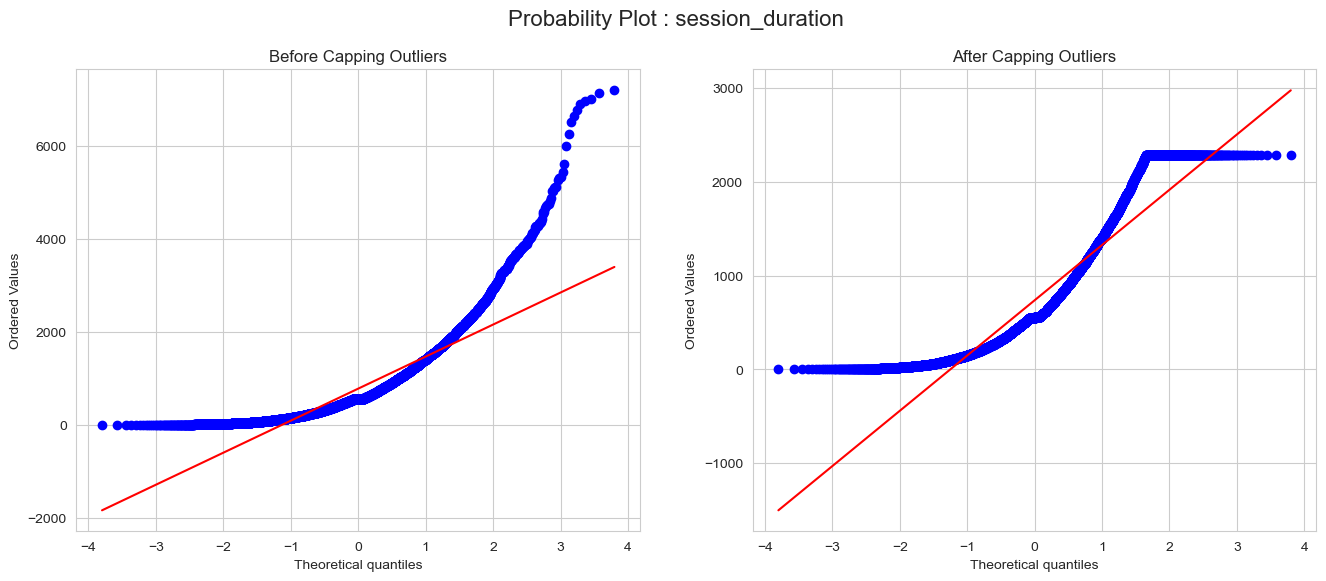

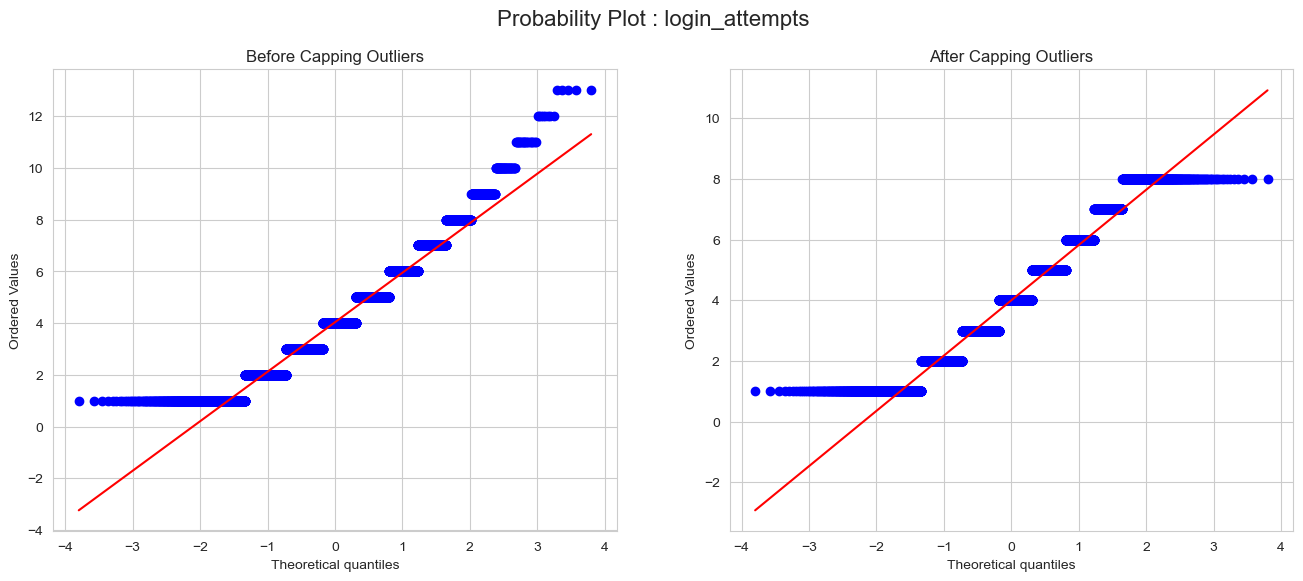

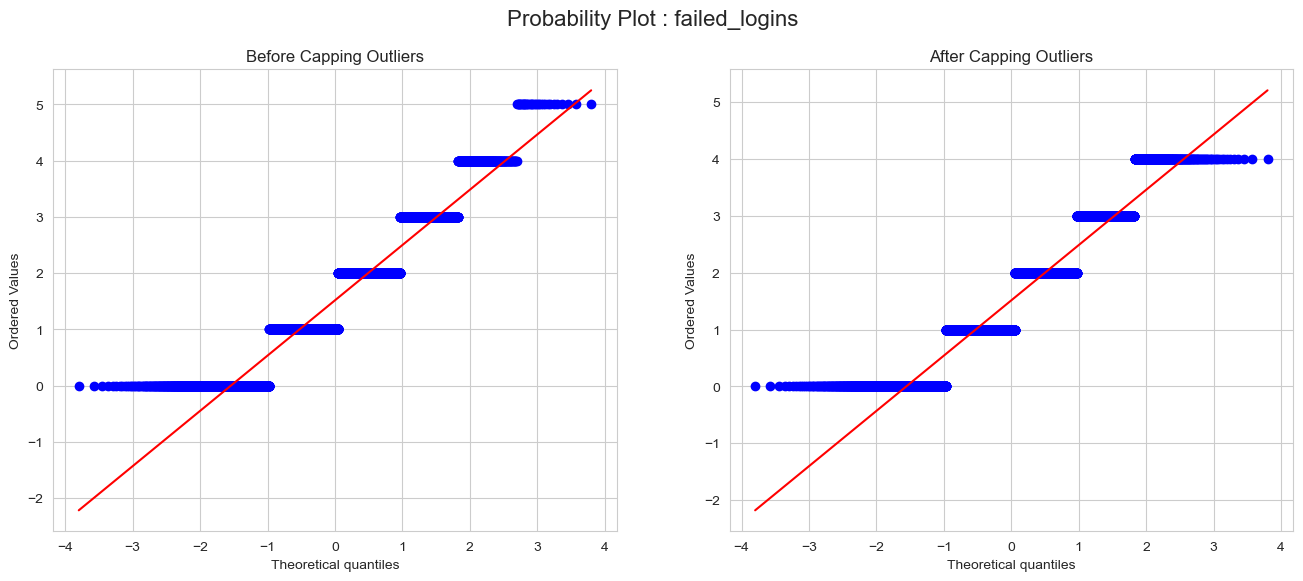

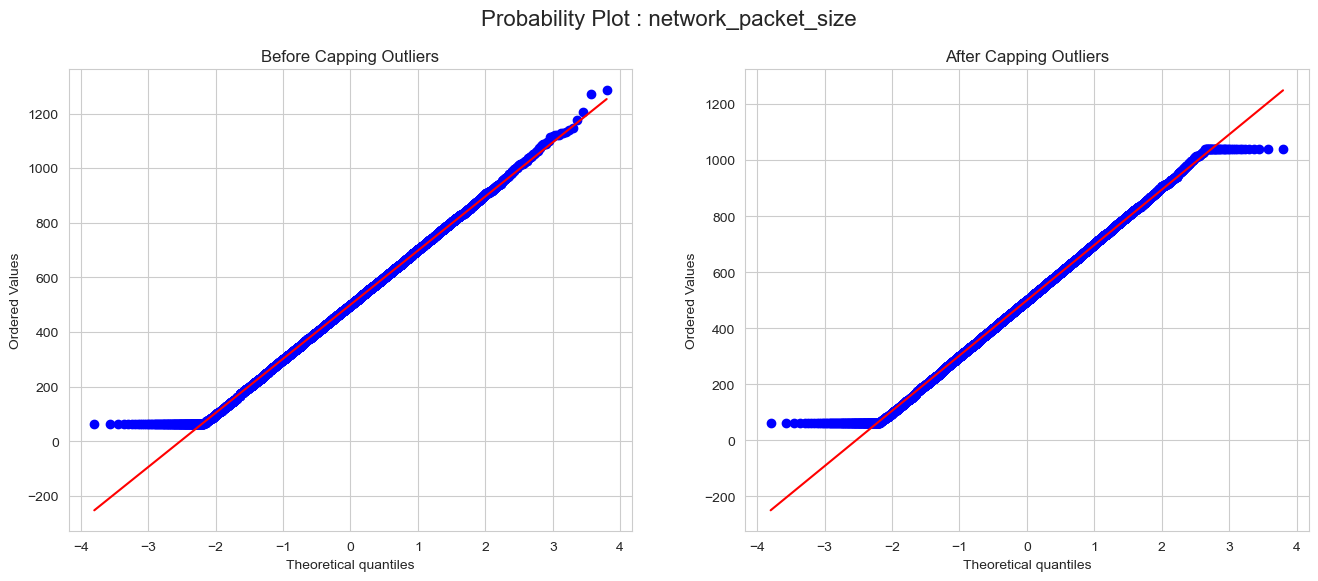

In [22]:
# Define list of columns to visualise
cols_to_visualize = ['session_duration', 'login_attempts', 'failed_logins', 'network_packet_size']

# Probability plots before and after handling outliers
for feature in cols_to_visualize:
    
    # Create the figure and a title
    sns.set_style('whitegrid')
    plt.figure(figsize=(16, 6))
    plt.suptitle(f'Probability Plot : {feature}', fontsize=16)

    # "Before" plot using copied df before capping
    plt.subplot(1, 2, 1)
    stats.probplot(df_before_capping[feature], plot=plt)
    plt.title(f'Before Capping Outliers')

    # "After" plot of DataFrame
    plt.subplot(1, 2, 2)
    stats.probplot(df[feature], plot=plt)
    plt.title(f'After Capping Outliers')

    # Display plot
    plt.show()


# 2. Exploratory Data Analysis (EDA)

I'm approaching the EDA from the standpoint of a cybersecurity team in order to comprehend its context and characteristics of potential cyberattack. The goal is to understand the characterisitcs related to the target variable 'attack_detected' and different analysts would focus on different features of the dataset.
     
The primay goal is to answer the question "What behaviors or network characterisitics are most indicative of a potential cyberattack to a given user" and I will explore the data from two main perspectives:

The Network Security Perspective: 
Focuses on network-level traffic. 
The key question is, "Can we identify an attack based on the technical characteristics of the network packets themselves?"

The User Behavior Perspective: 
Focuses on how users are interacting with the system. 
The key question is, "Are there user actions that are strong indicators of a compromised account or an attack?"

My initial hypothese which are grounded in domain knowledge are:

- I expect that a high number of 'failed_logins' will be strongly associated with a detected attack and inturn a sign of brute-force attempt.

- Sessions that have 'encryption_used' set to 'none' or 'unknown' in my opinion, may be an indicator of attacks using unencrypted techniques.

- I expect that session duration that is abnormally long or short in comparison to typical users will be a sign of an attack.

 Percentage Distribution: attack_detected
0    55.29%
1    44.71%
Name: proportion, dtype: object


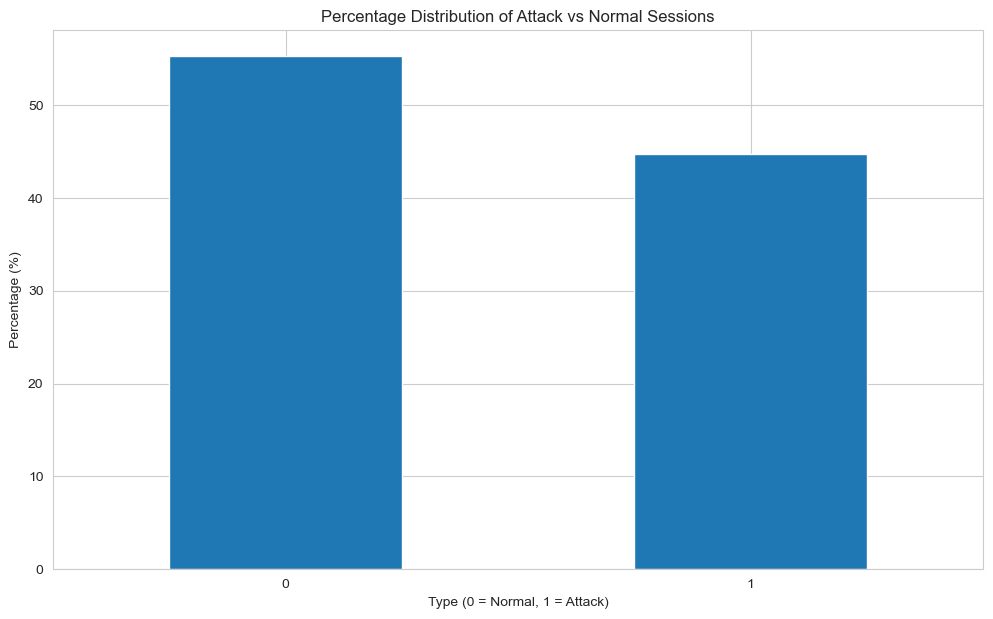

In [23]:
# Understand the proportion of attacks to normal session with the traget variable 'attack_detected'
target_var_attack_percentages = df['attack_detected'].value_counts(normalize=True) * 100

# show percentage distribution percentages
print(f" Percentage Distribution: {target_var_attack_percentages.map('{:.2f}%'.format)}")

# Create the bar plot.
plt.figure(figsize=(12, 7))
target_var_attack_percentages.plot(kind='bar')

# Plot labels 
plt.title('Percentage Distribution of Attack vs Normal Sessions')
plt.xlabel('Type (0 = Normal, 1 = Attack)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

# Display plot
plt.show()

The distribution of the target variable 'attack_detected' shows that the dataset is well balanced. 
The dataset approximately is 55.29% classified as "Normal" (0) and 44.71% as "Attack" (1).

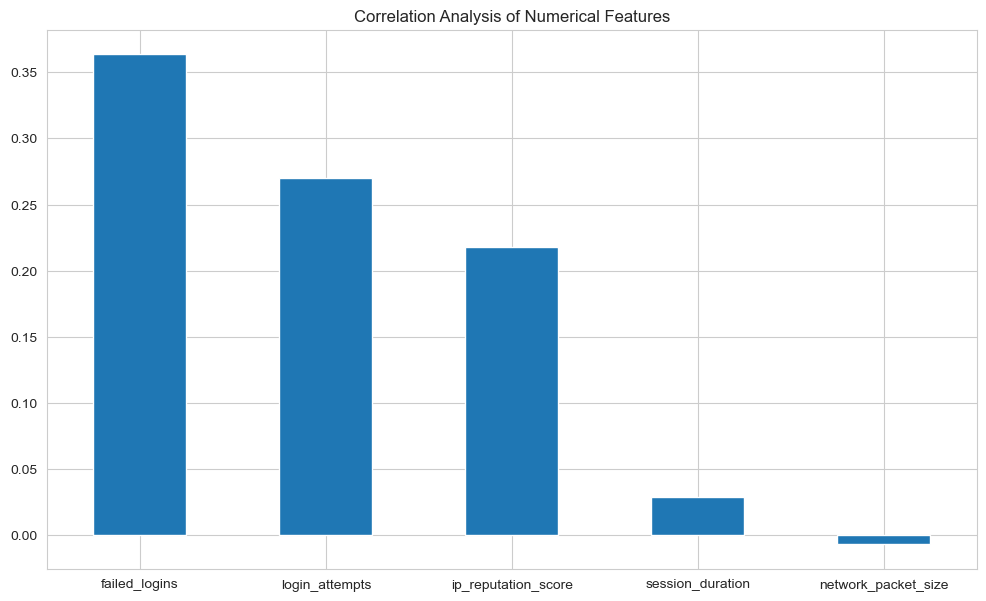

In [24]:
# Define numerical columns from DataFrame
numerical_columns = df.select_dtypes(include=[np.number]).columns

# Bar plot of Correlation with 'attack_detected' and remove unusual_time_access as this is a categorical feature.
plt.figure(figsize=(12, 7))
df[numerical_columns].corr()['attack_detected'].drop(['attack_detected','unusual_time_access']).sort_values(ascending=False).plot(kind='bar')

# Plot labels 
plt.title('Correlation Analysis of Numerical Features')
plt.xticks(rotation=0) 

plt.show()

The correlation bar plot analyse shows the relationships between numerical features and the target variable attack_detected.

The analysis shows that user behavior metrics are strong predictors of potential threats. The 'failed_logins' and 'login_attempts' shows a strong positive linear relationship with attack_detected.

A new insight was that the 'ip_reputation_score' also had a notable postive correlation. The IPs with a high score are more likely to be involved in an attack. Higher values indicate suspicious activity.

The session_duration and network_packet_size show weak correlations.

The analysis highlights user behavior metrics (e.g., login_attempts, IP reputation) as strong predictors of potential cybersecurity threats and helps prioritise features for further analysis.

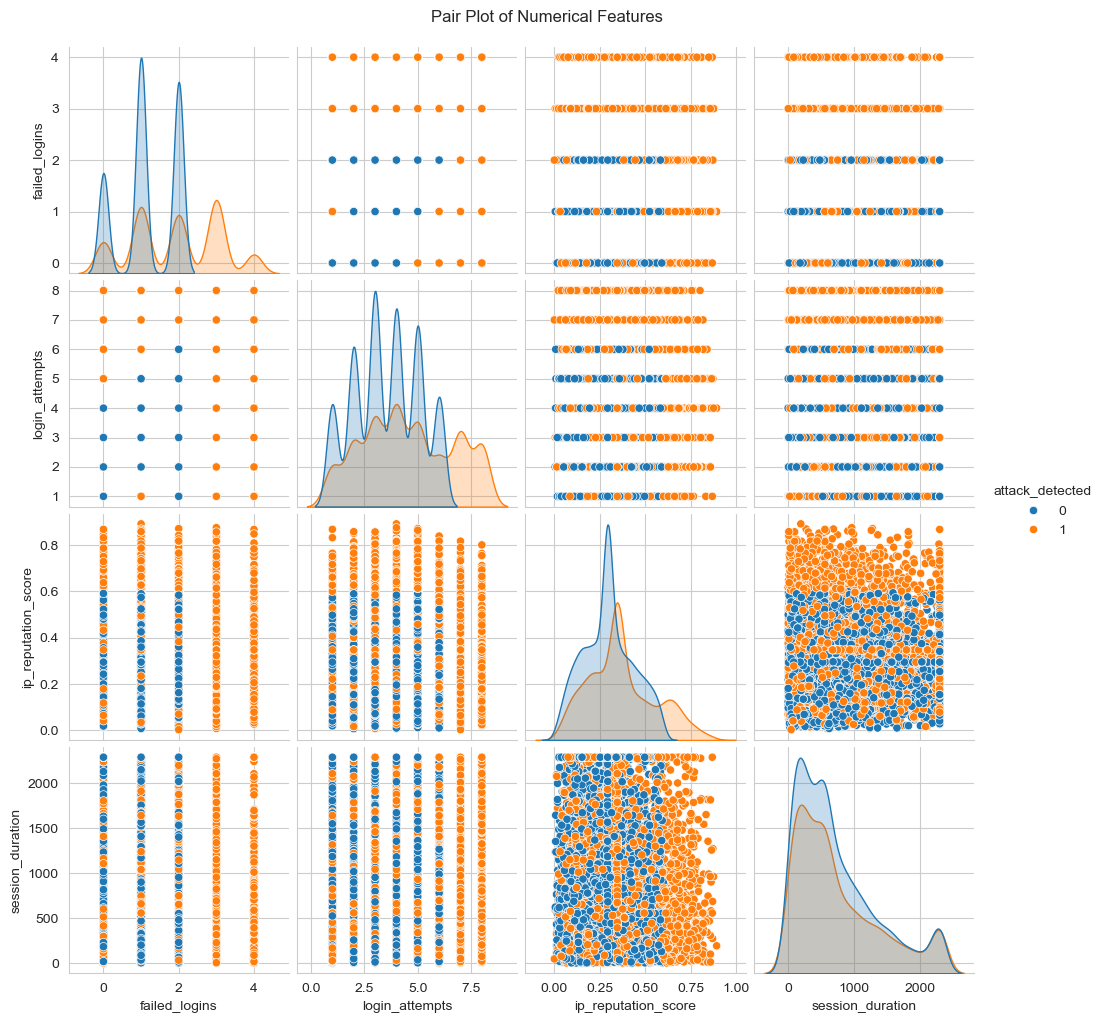

In [25]:
# Create the pair plot showing relationship between each pair of variables by target variable 'attack_detected' - coloured (orange)
numerical_pair_plot = sns.pairplot(
    df[['failed_logins', 'login_attempts','ip_reputation_score', 'session_duration', 'attack_detected']],
    hue='attack_detected')

# Plot labels
numerical_pair_plot.figure.suptitle('Pair Plot of Numerical Features', y=1.02)

# Display plot
plt.show()

The pair plot analysis on numerical features are distributed and interact differently for each class within the attack_detected target variable (Normal vs. Attack).

The pair plot shows that the distributions for attacks are different from normal session data. The features 'failed_logins', 'login_attempts' and 'ip_reputation_score' distributions for attacks is shifted towards higher values. 

The 'session_duration' shows that normal sessions (blue) account for both shortest and  most long durations. The attack sessions (orange) are more consistently clustered in a low to moderate duration range and lack the extremely long session times.

The relationship between ip_reputation_score and failed_logins shows a cluster of attack sessions located in the region where both the IP score is high and the number of failed logins is high.

The ip_reputation_score and session_duration plot shows a cluster of attacks characterized by a high IP score and regardless of the session's length.

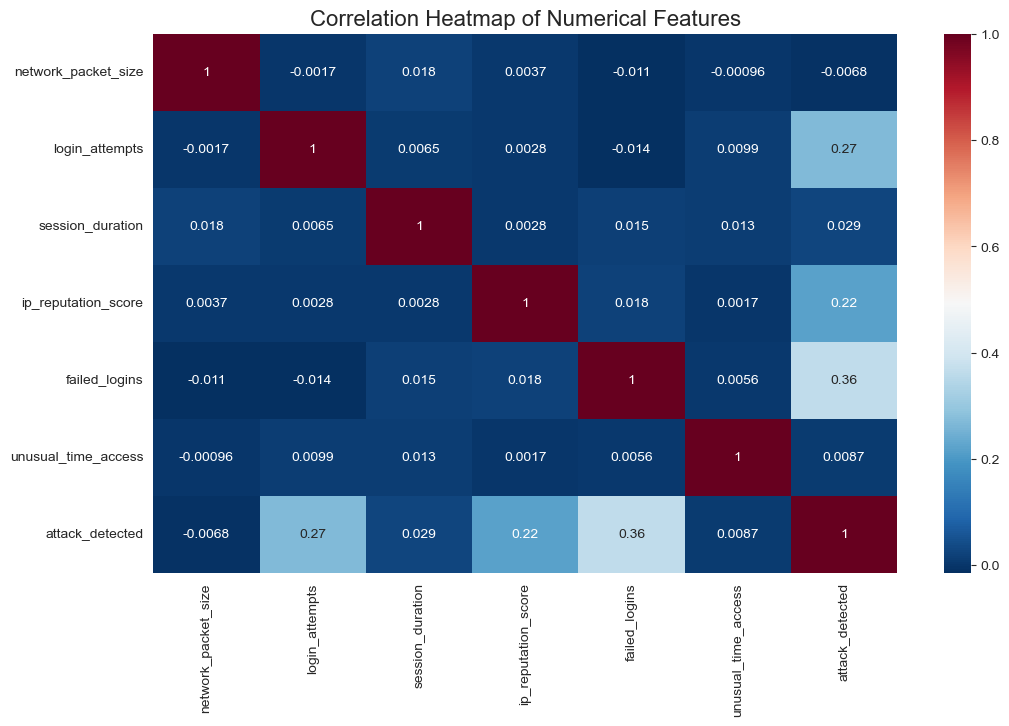

In [26]:
# Create an  correlation matrix form numerical columns from the DataFrame.
numerical_columns_df = df.select_dtypes(include=['number'])

# Create plot
plt.figure(figsize=(12, 7))
sns.heatmap(numerical_columns_df.corr(), annot=True, cmap='RdBu_r')

# Plot labels 
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)

# Display plot
plt.show()

The correlation heatmap provides insight into which features are most likely to provides immediate, strong evidence that metrics are critical and justifies a deeper investigation in the following sections.

The features with the strongest positive correlation to attack_detected are ip_reputation_score, failed_logins, and login_attempts. The heatmap provides immediate evidence that these user behavior metrics are are important and need further investigation.

session_duration, network_packet_size and unusual_time_access show very weak linear correlations with the target variable.

### 2.1 EDA: User Behavior

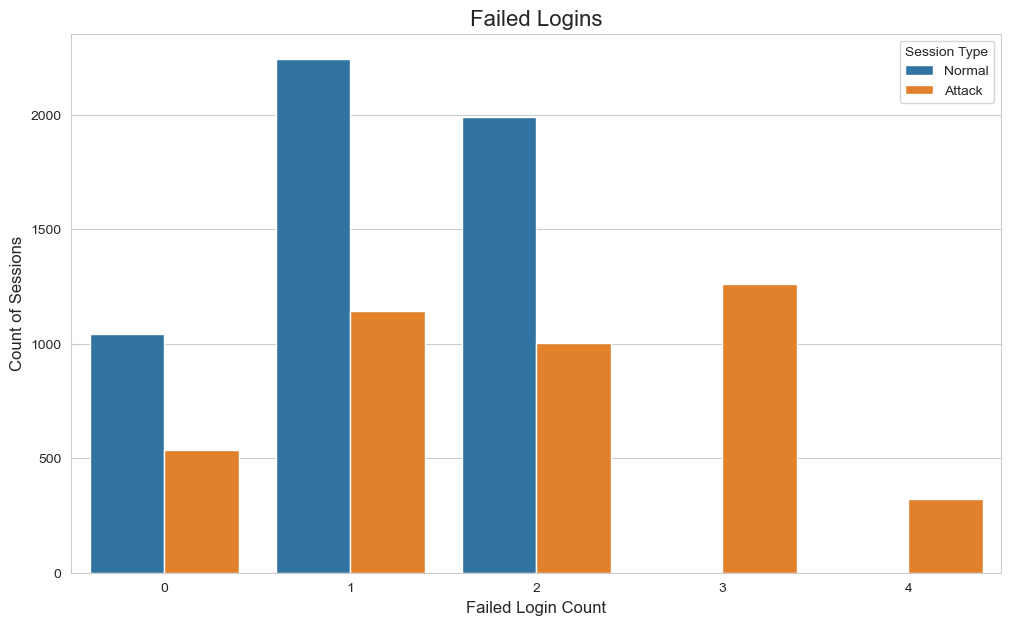

In [27]:
# Create countplot to visualize the failed_logins agianst target value - attack_detected
plt.figure(figsize=(12, 7))
sns.countplot(x='failed_logins', hue='attack_detected', data=df)

# Plot labels
plt.title('Failed Logins', fontsize=16)
plt.xlabel('Failed Login Count', fontsize=12)
plt.ylabel('Count of Sessions', fontsize=12)
plt.legend(title='Session Type', labels=['Normal', 'Attack'])

# show plot
plt.show()

The frequency of failed logins for normal versus attack sessions shows strong evidence that higher 'failed_logins' is a characteristic of a potential attack.

Sessions with 0 or 1 failed logins are overwhelmingly classified as "Normal". 

The sessions with two or more unsuccessful login attempts are labelled as "Attack" sessions and no "Normal" sessions are included.

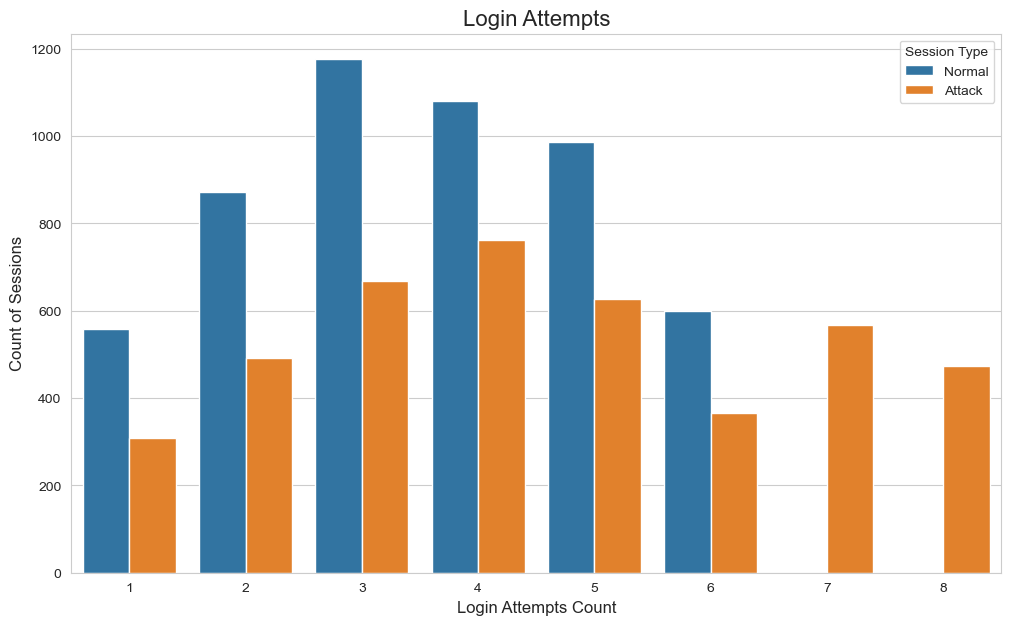

In [28]:
# Create countplot to visualize the login_attempts agianst target value - attack_detected
plt.figure(figsize=(12, 7))
sns.countplot(x='login_attempts', hue='attack_detected', data=df)

# Plot labels
plt.title('Login Attempts', fontsize=16)
plt.xlabel('Login Attempts Count', fontsize=12)
plt.ylabel('Count of Sessions', fontsize=12)
plt.legend(title='Session Type', labels=['Normal', 'Attack'])

# show plot
plt.show()

The 'login_attempts' feature is a strong indicator of an attack from the "User Behavior Perspective".

Sessions with a lower number of login attempts are predominantly "Normal". As the number of attempts increases, the proportion of "Attack" sessions rises significantly. Sessions with four or more login attempts are far more likely to be malicious.

A high number of login attempts on a session is a characteristic of a potential attack.

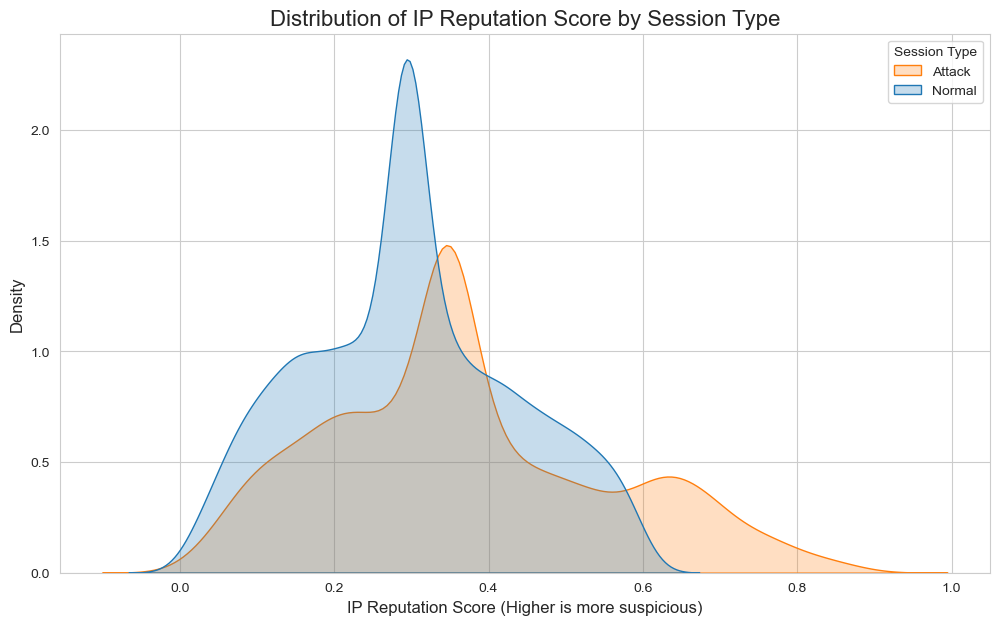

Mean Distribution of IP Reputation Score by Session Type
attack_detected
0    0.30
1    0.37
Name: ip_reputation_score, dtype: object


In [29]:
# Create KDE plot to compare the distributions of the ip_reputation_score agianst target value - attack_detected
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='ip_reputation_score', hue='attack_detected', fill=True)

# Add labels and a title
plt.title('Distribution of IP Reputation Score by Session Type', fontsize=16)
plt.xlabel('IP Reputation Score (Higher is more suspicious)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Session Type', labels=['Attack', 'Normal'])
plt.show()

# To support the analysis with a precise number group the DataFrame by the 
# 'attack_detected' status and calculate the mean 'ip_reputation_score' for each group
ip_mean_by_group = df.groupby('attack_detected')['ip_reputation_score'].mean()

# Print the resulting series
print("Mean Distribution of IP Reputation Score by Session Type")
print(ip_mean_by_group.map('{:.2f}'.format))


A Kernel Density Estimate (KDE) plot was used to visualize the distribution of the 'ip_reputation_score' distribution between "Normal" and "Attack". 

The "Normal' (blue) shows a sharp high peak with low IP reputation score, where the bulk of the legitimate sessions almost always originate from IPs with a good reputation.

The "Attack" (orange) has its main peak at a higher IP reputation score, where the bulk of the malicious activity typically originate from IPs with a low reputation.

The mean ip_reputation_score was calculated for each group. The output confirms a significant difference in the central tendency of the two distributions:

The mean distribution score for "Normal" sessions is 0.30 and for "Attack" sessions is 0.37. Evidence that the central tendency of the ip_reputation_score distribution is higher for "malicious" sessions and is a key characteristic of attack data in dataset.

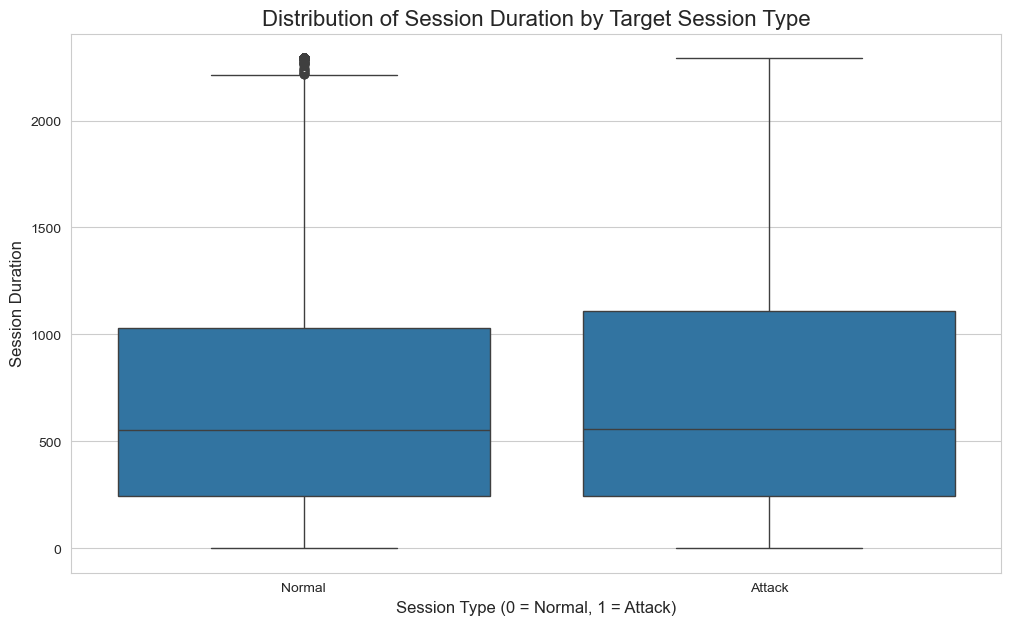

Median Session Duration by Session Type:
attack_detected
0    551.28
1    556.87
Name: session_duration, dtype: object


In [30]:
# Create boxplot to visualize the distribution of 'session_duration' further
plt.figure(figsize=(12, 7))
sns.boxplot(x='attack_detected', y='session_duration', data=df)

# Plot labels
plt.title('Distribution of Session Duration by Target Session Type', fontsize=16)
plt.xlabel('Session Type (0 = Normal, 1 = Attack)', fontsize=12)
plt.ylabel('Session Duration', fontsize=12)
plt.xticks([0, 1], ['Normal', 'Attack'])

# show plot
plt.show()

# Caculate median session duration of attack_detected types
median_durations = df.groupby('attack_detected')['session_duration'].median()

# Print the results in a clear format
print("Median Session Duration by Session Type:")
print(median_durations.map('{:.2f}'.format))


Analysis of 'session_duration' with box plot for more direct comparison of between normal and attack sessions reveals that the  median session duration for attacks is slightly higher than for normal sessions. But,the main cluster of normal sessions is very concentrated (a short box) and also represents all of the long sessions, indicated by the outliers.

The attack sessions are variability in their typical range but consistently lack these extreme long duration outliers.Attack sessions show more variability in their typical range but  lack these extreme long-duration outliers.

A prolonged session activity is not a characteristic of a potential attack.

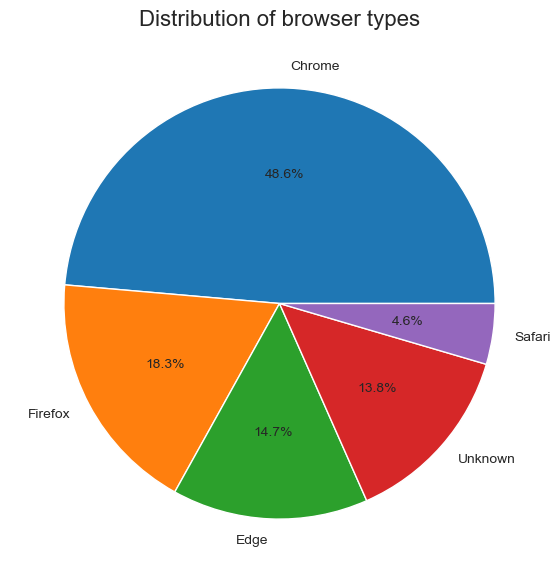

In [31]:
# calculate the count of each unique value in the 'browser_type' column
browser_types = df['browser_type'].value_counts()

# define the labels for the pie chart
browser_type_values = ['Chrome','Firefox','Edge','Unknown','Safari']

# Plot labels
plt.figure(figsize=(10, 7))
plt.pie(browser_types,autopct='%1.1f%%',labels=browser_type_values)
plt.title('Distribution of browser types', fontsize=16)

# show plot
plt.show()

The general distribution of browser type to get insight of the proportion of sessions originating from each browser type.

Chrome is the most frequently used browser, followed by Firefox, Edge, and Safari. The 'unknown' category represents non-standard or unidentifiable client also contributes a notable portion of the traffic.

While this visualization is useful for insight into the general distribution of browsers, it does not show how these categories relate to the target variable 'attack_detected'. I will investigate further with a grouped count plot agianst target varaible 'attack_detected'.

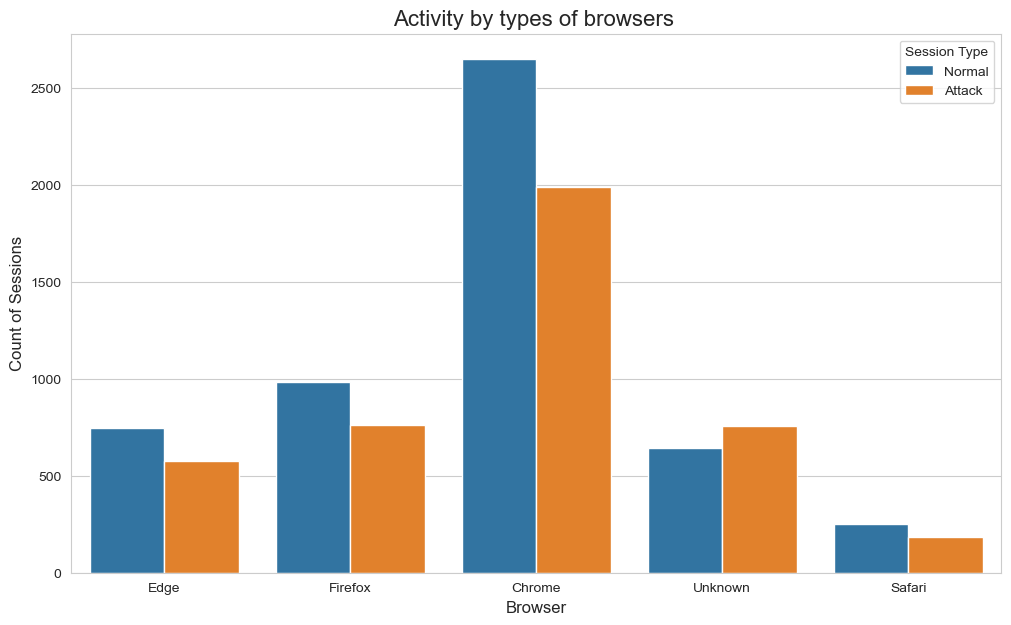

In [32]:
# Create countplot to browser_type against target varaible
plt.figure(figsize=(12, 7))
sns.countplot(x='browser_type', hue='attack_detected', data=df)

# Plot labels
plt.title(f'Activity by types of browsers ', fontsize=16)
plt.xlabel('Browser', fontsize=12)
plt.ylabel('Count of Sessions', fontsize=12)
plt.legend(title='Session Type', labels=['Normal', 'Attack'])

# show plot
plt.show()

The likelihood of a session being an attack does not differ significantly across major browsers such as Chrome, Firefox, Edge and Safari, where the proportion of normal to malicious traffic is relatively consistent. 
 
This indicates that the choice of a specific mainstream browser is not a strong indicator of attack.

Sessions where the browser_type is 'Unknown' are significantly more likely to be malicious and is a strong indicator. Applying domain knowledge that attackers traffic from non-standard clients, bots or scripts don't identify themselves with a standard browser.

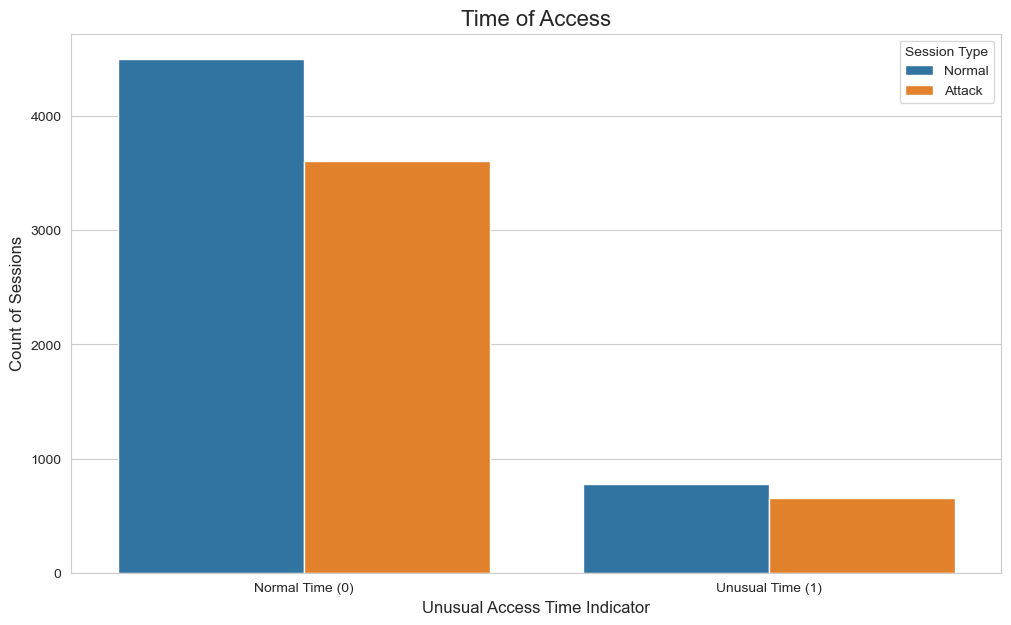

In [33]:
# Create countplot to unusual_time_access against target varaible
plt.figure(figsize=(12, 7))
sns.countplot(x='unusual_time_access', hue='attack_detected', data=df)

# Plot labels
plt.title('Time of Access', fontsize=16)
plt.xlabel('Unusual Access Time Indicator', fontsize=12)
plt.ylabel('Count of Sessions', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Normal Time (0)', 'Unusual Time (1)'])
plt.legend(title='Session Type', labels=['Normal', 'Attack'])

# show plot
plt.show()

The countplot shows that the sessions occurring at unusual times are equally classified as attacks and normal. 

unusual_time_access could be a strong indicator of a potential attack, validating domain knowledge that attackers often operate outside of standard hours to perform attacks.

To ensure accuracy due to the imbalanced of sessions in individual target variable (attack_detected).

I'll quantitativly analyse the attack rates for each category to further understanding of the features data.

In [34]:
# Group by unusual_time_access category and get the value counts as a proportion
attack_proportions_pct = df.groupby('unusual_time_access')['attack_detected'].value_counts(normalize=True)

# Format the to show a percentage
print("plot proportions percentage")
print((attack_proportions_pct * 100).map('{:.2f}%'.format))

plot proportions percentage
unusual_time_access  attack_detected
0                    0                  55.47%
                     1                  44.53%
1                    0                  54.27%
                     1                  45.73%
Name: proportion, dtype: object


The 'unusual_time_access' initial analysis showed a strong indicator of a potential attack, the quantitative analyse of attack rates for each category shows that the attack rate is nearly identical for both categories, 44.53% for sessions during normal hours and 45.73% for sessions during unusual hours.

This finding contradicts the initial findings and 'unusual_time_access' is not a strong indicator of a potential attack, as the likelihood of an attack is nearly identical for both categories regardless of the time of access.

### 2.2 EDA: Session Network

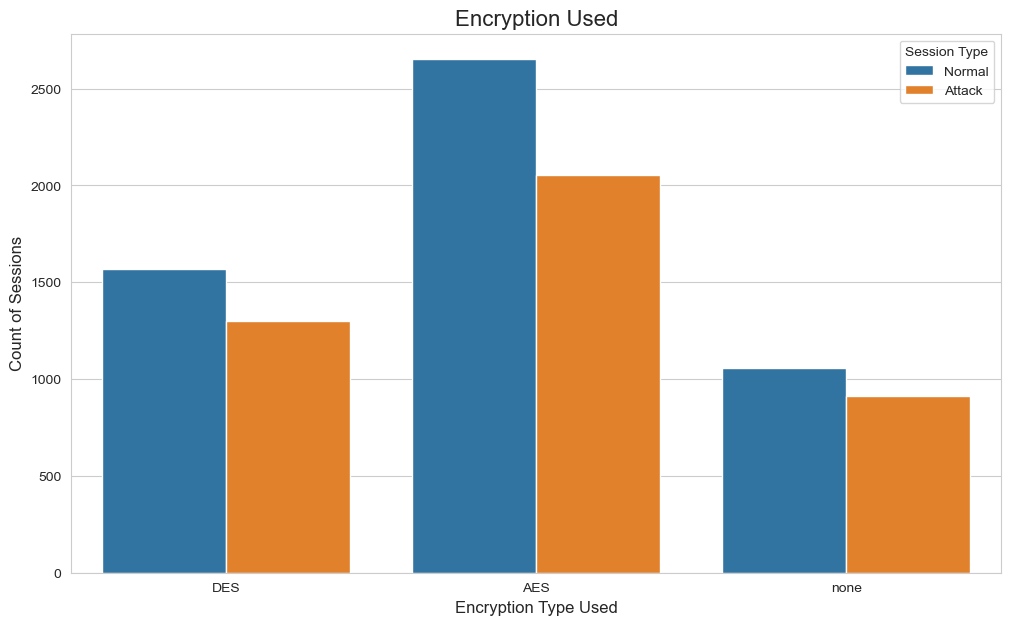

In [35]:
# Create countplot to visualize the encryption types
plt.figure(figsize=(12, 7))
sns.countplot(x='encryption_used', hue='attack_detected', data=df)

# Plot labels
plt.title('Encryption Used', fontsize=16)
plt.xlabel('Encryption Type Used', fontsize=12)
plt.ylabel('Count of Sessions', fontsize=12)
plt.legend(title='Session Type', labels=['Normal', 'Attack'])

# show plot
plt.show()

Analysis of encryption type used in sessions could be an indicator of malicious activity. 

The analysis shows for sessions using standard protocols for AES and DES the majority are classified as "Normal".

Sessions where the encryption type is "none," shows an significantly higher count of "Attack" sessions compared to "Normal".

The 'encryption_used' feature is a strong indicator of a potential attack.

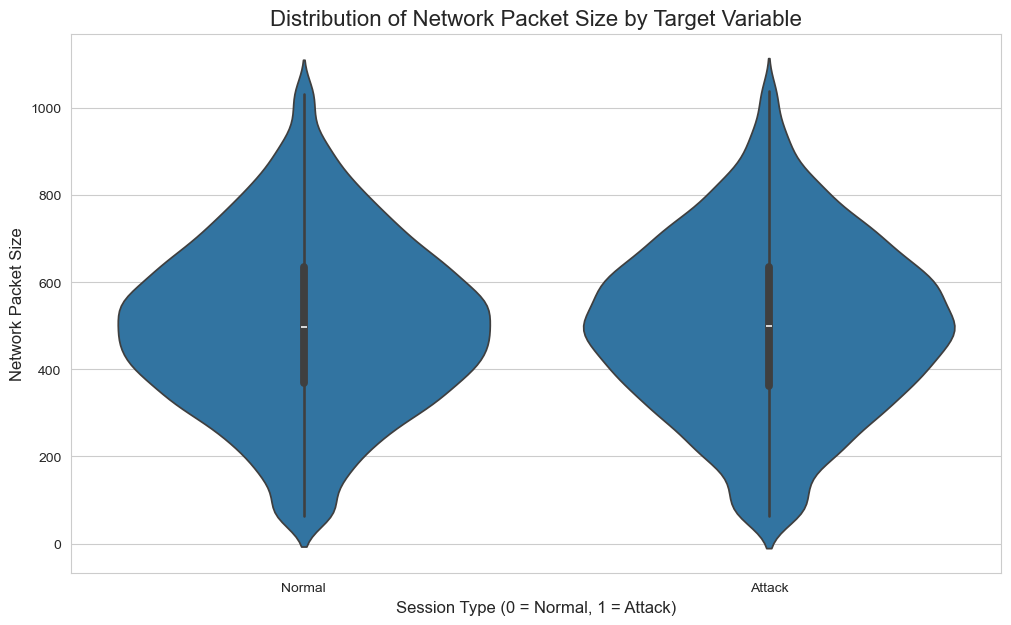

In [36]:
# Create violin plot to comparing distributions network_packet_size by target variable 'attack_detected'
plt.figure(figsize=(12, 7))
sns.violinplot(x='attack_detected', y='network_packet_size', data=df)

# Plot labels
plt.title('Distribution of Network Packet Size by Target Variable', fontsize=16)
plt.xlabel('Session Type (0 = Normal, 1 = Attack)', fontsize=12)
plt.ylabel('Network Packet Size', fontsize=12)
plt.xticks([0, 1], ['Normal', 'Attack'])

# show plot
plt.show()

Analysis of whether sesions 'network_packet_size' has any potential attack predictive value, despite its weak linear correlation with the target variablie.

The distribution of 'network_packet_size' is the same for both normal and attack sessions and confirms that Network Packet size may not be a useful predictor of an potential attack and this also confirms the weak correlation I found earlier. I can confidently decide to focus on other impactful features.

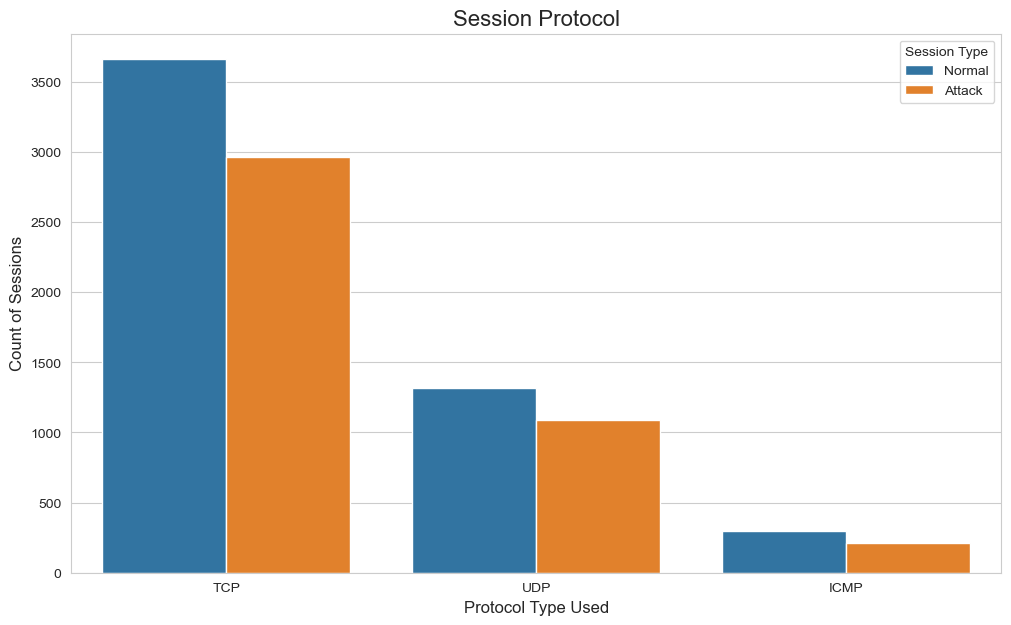

In [37]:
# Create countplot to visualize the protocol_types by target variable
plt.figure(figsize=(12, 7))
sns.countplot(x='protocol_type', hue='attack_detected', data=df)

# Plot labels
plt.title('Session Protocol', fontsize=16)
plt.xlabel('Protocol Type Used', fontsize=12)
plt.ylabel('Count of Sessions', fontsize=12)
plt.legend(title='Session Type', labels=['Normal', 'Attack'])

# show plot
plt.show()

TCP & UDP are two common protocol and have faily even number of "Attack" and "Normal" sessions. ICMP session protocol is low in this dataset but balanced in terms of normal and attack sessions.

To further analysie whether the network protocol is a good predictor of an attack, I will perform quantitative analysis on the distribution of "Attack" and "Normal" category in each protocol.

In [38]:
# Group by protocol_type and calculate the distribution of attacks in each group
attack_rate_by_protocol = df.groupby('protocol_type')['attack_detected'].value_counts(normalize=True)

# Multiply by 100 and format as a percentage string
print("--- Attack Rate by Protocol Type ---")
print((attack_rate_by_protocol * 100).map('{:.2f}%'.format))

--- Attack Rate by Protocol Type ---
protocol_type  attack_detected
ICMP           0                  58.78%
               1                  41.22%
TCP            0                  55.27%
               1                  44.73%
UDP            0                  54.61%
               1                  45.39%
Name: proportion, dtype: object


The quantitative analysis shows that the distribution for both "Attack" and "Normal" category is identical across all three protocols: 44.73% for TCP, 45.39% for UDP and 41.22% for ICMP.

In this dataset the 'protocol_type' is not a strong predictor of malicious activity as the likelihood of an attack is consistent regardless of the protocol used.

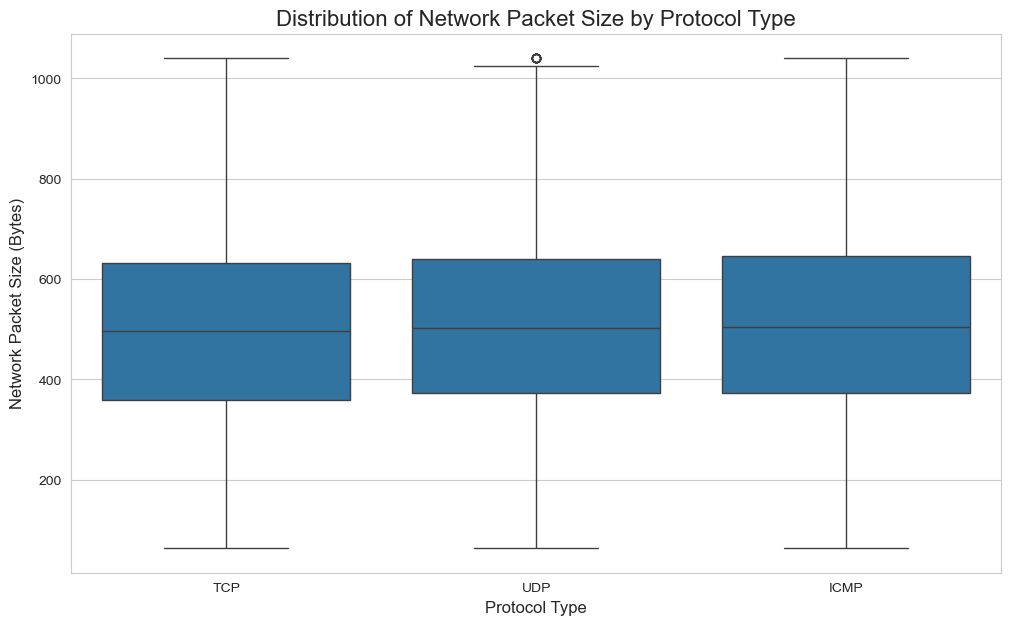

                count        mean         std   min    25%    50%    75%  \
protocol_type                                                              
ICMP            507.0  504.171598  196.424633  64.0  374.0  505.0  645.5   
TCP            6624.0  497.832880  198.051487  64.0  359.0  497.0  632.0   
UDP            2406.0  505.824190  196.720673  64.0  374.0  502.0  639.0   

                  max  
protocol_type          
ICMP           1040.0  
TCP            1040.0  
UDP            1040.0  


In [39]:
# Create boxplot to visualize the distribution of 'session_duration' further
plt.figure(figsize=(12, 7))
sns.boxplot(x='protocol_type', y='network_packet_size', data=df)

# Plot labels
plt.title('Distribution of Network Packet Size by Protocol Type', fontsize=16)
plt.xlabel('Protocol Type', fontsize=12)
plt.ylabel('Network Packet Size (Bytes)', fontsize=12)

# show plot
plt.show()

# Group 'protocol_type' and describe the 'network_packet_size' for each group
stats_summary_by_protocol = df.groupby('protocol_type')['network_packet_size'].describe()
print(stats_summary_by_protocol)

My initial analysis of network_packet_size looked at its overall distribution compared to 'attack_dected' flag and made conclusion that it was a weak predictor of an attack. However, to make an informed advanced feature engineering feature, I returned to EDA to test a specific hypothesis, "that the median size of a network packet dependent on 'protocol_type' can be a predictor of attack"

The distribution box plot shows packet size of TCP, UDP, and ICMP are very similar and not having a very distinct median range for a "normal" packet size of each protocol.

The exploration clarfied the decision to create an advanced freature that caculates a network packet size relative to the norm for it's specific protocol. The means and standard deviations for TCP, UDP, and ICMP are all closely clustered and caluation of deviations would be redundant and adds no new information for the model.

# 2.3 EDA Conclusion 

Exploratory Data Analysis (EDA) identified the key characteristics of cyberattacks within the dataset by analysing the data from two distinct perspectives.

The analysis confirmed that user actions are highly predictive of an attack. Features such as failed_logins, login_attempts and a high ip_reputation_score are the strongest indicators. 

The analysis further improved the original session_duration theory. Only normal users have extremely long sessions (the outliers). Attacks, on the other hand consistently stay in a more limited session duration and never last as long as normal users. The absence of prolonged user activity is a key indicator of an attack.

From a network security standpoint the analysis identified several features indicators. The absence of encryption (encryption_used = 'none') and traffic from 'unknown' browsers are both strongly associated with malicious sessions.

Based on these insights identified in this EDA, a key question I would like explore next is:

"Can a machine learning model be trained to accurately classify cyberattacks in sessions with a combination of the user behavior and network features?"

# 3. Feature Engineering and Project re-evaluation

The exploratory data analysis uncovered several dataset feature patterns linked to cyberattacks. I will transform the raw data of these features into a format which can be used to train model.

Having thought about this dataset further, a standard approach would be to use the target variable 'attack_detected' to train a supervised classification model.
However, after reflecting on this dataset and a real-world cybersecurity context, I am pivoting to a more realistic strategy with the dataset.

Project re-evaluation: Unsupervised Anomaly Detection

After further reflecting on this dataset and an real-world cybersecurity context. Data of user behavior and network don't come with flags that indicate a real world attack. 'attack_detected' as such in my dataset. 

A more real-world application of machine learning strategy is to learn identify "attack" session in a sea of normal sessions.The objective of this project as an unsupervised anomaly detection problem using unsupervised approach which trains to define 'normal' session is more real-world industry application. 

This approach allows the model to learn 'normal' patterns present in the training data and allow the potential to identify  "attack" patterns.  

By utilising the the dataset 'attack_detected' columns 'attack' sessions I will be able to validate the model's accuracy at the end to confirm how effectively the model identified the true "attack" sessions as anomalies.

1. Supervised Classification: Trained using the 'attack_detected' labels to establish a baseline performance for identifying known attack patterns.
2. Unsupervised Anomaly Detection: A model trained only on "normal" data to simulate a more realistic scenario where attack labels are unknown during training.

By comparing the performance and characteristics of both methods I aim to understand a deeper insight into the effectiveness and trade-offs of different machine learning strategies for intrusion detection on this dataset.

In [40]:
# Show dataset columns by numerical and categorical 
numerical_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

print("\n")

# Show unique values for each categorical column
print("Unique values in categorical columns")
for col in categorical_columns:
    # .unique() returns an array of the unique values in the column
    unique_values = df[col].unique()
    print(f"Column '{col}': {unique_values}")

print("\n")
# Show summary of each numerical columns
print("Summary of numerical colums")
df[numerical_columns].describe().transpose()

Numerical columns: Index(['network_packet_size', 'login_attempts', 'session_duration',
       'ip_reputation_score', 'failed_logins', 'unusual_time_access',
       'attack_detected'],
      dtype='object')
Categorical columns: Index(['protocol_type', 'encryption_used', 'browser_type'], dtype='object')


Unique values in categorical columns
Column 'protocol_type': ['TCP' 'UDP' 'ICMP']
Column 'encryption_used': ['DES' 'AES' 'none']
Column 'browser_type': ['Edge' 'Firefox' 'Chrome' 'Unknown' 'Safari']


Summary of numerical colums


,count,mean,std,min,25%,50%,75%,max
network_packet_size,9537.0,500.185908,197.641910,64.000000,365.000000,499.000000,635.000000,1040.000000
login_attempts,9537.0,3.996330,1.867712,1.000000,3.000000,4.000000,5.000000,8.000000
session_duration,9537.0,737.116794,628.324880,0.500000,243.582773,551.282386,1062.794828,2291.612911
ip_reputation_score,9537.0,0.329193,0.163169,0.002497,0.213586,0.310971,0.422013,0.891286
failed_logins,9537.0,1.514313,1.023953,0.000000,1.000000,1.000000,2.000000,4.000000
unusual_time_access,9537.0,0.149942,0.357034,0.000000,0.000000,0.000000,0.000000,1.000000
attack_detected,9537.0,0.447101,0.497220,0.000000,0.000000,0.000000,1.000000,1.000000


Findings: 

- The dataset contains categorical columns with text value, and numerical columns with values vastly at different scales. i.e, 'session_duration' has a range in the thousands and 'ip_reputation_score' is a range between 0 and 1.

Categorical Features: 

- The exploratory data analysis identified the following categorical 'protocol_type','encryption_used' and 'browser_type', These features do not have an intrinsic order or rank.

- If I were to use a technique like Label Encoding it would assign integers (e.g., TCP=0, UDP=1, ICMP=2). A LabelEncoder would turn them into arbitrary numbers that the model might then learn a false mathematical relationship.

- I will utilize One-Hot Encoding to avoids this by not assuming any order at all and transforms each category into a new binary column. This represents the categories as independent value without imposing any  order. Given that all my categorical features are low-cardinality, this approach is the most accurate way to prepare the data for the model.


Numerical Features: 

- The numerical features colums are a mix of different scales, I will apply numerical scaling to treat each feature with equal importance. This is performed to prevent features with large numerical ranges from unfairly dominating the anomaly detection process.

# 3.1 New Features

Beyond just the raw dataset, I aim to engineer new features applying cybersecurity domain knowledge as foundation for these new features.

With the observation made in the EDA, extreme and rare values provides powerful signals. I am creating new binary features to capture these extreme behaviors to allow for more easier prediction. 

### User Behavior Rates
1) Login Failure Rate: Indicator of brute-force attack on an account, this will be caculated as a ratio of failed_logins divided by login_attempts ('failed_logins' / 'login_attempts') 

2) Unnsual Rate: An indicator created based on mutiple suspicious indicator features occuring together, this features will be based on ('failed_login' * 'unusual_time_access' * risk from 'ip_reputation_score')

### Network Behavior
1) Long Session: The 'session_duration' boxplot showed that attack sessions have longer durations. The binary flag will indicate 'True' for sessions longer than the 90th percentile of the data distribution. Signaling  potentially malicious and persistent connections as a high-precision signal.  

2) High Login Attempts: This flag will indicate unusually high number of attempts. EDA showed that the 75th percentile for login_attempts is 5.0. 75% of all sessions in the dataset have 5 or less login attempts.  The 'login_attempts' summary showed a maximum of 8 and setting threshold at > 5 creates a flag for behavior that is statistically the top 25% outside the typical range of users. This approach specifically isolates the most extreme and potentially suspicious attempt counts.

3) Session Properties: Applying cybersecurity domain knowledge, certian sessions with combined rare features as low quality network properties can provide stonge indicator of attack session. For example: An attacker might use a browser (i.e. None) and a common network protocol (i.e TCP) abd weak encryption (i.e DES). This specific combination is something that might never happen in normal session. 

~~4) Network Packet Size Deviation: The deviation of 'network_packet_size' by distribution by 'network_protocol' type.~~ 
My initial EDA looked a colleration of the network_packet_size to the 'attack_detected' flag. During the feature engineering phase, I've developed a more advanced hypothesis, "the median size of a network packet dependent on 'protocol_type' can be a predictor of attack"

However after completing a supporting EDA showed that the network_packet_size means and standard deviations for TCP, UDP, and ICMP  to are very  similar. Therefore, creating a deviation feature would provide redundant information, and I have chosen not to implement it.

In [41]:
# Create user behavior rates features based on copy of dataframe
df_engineered = df.copy()

# small value to added to denominators to prevent code error when dividing by zero.
small_value = 0.00001

# 1) Caculate feature 'login_failure_rate'
# Calculates ratio of failed login / total attempts ratio.
df_engineered['login_failure_rate'] = (
    # The 'failed_logins' as numerator of ratio
    df_engineered['failed_logins'] /
    # The 'login_attempts' as denominator and add small value (incase failed_login is zero)
    (df_engineered['login_attempts'] + small_value)
)

# 2) Caculate feaure 'unusual_rating'
# Caculate feature by multiplying risk factor colums. 
# The caculation will only be high when multiple suspicious events happended in a session.
df_engineered['unusual_rating'] = (
    # number of failed logins for the session
    df_engineered['failed_logins'] * 
    # unusual_time_access' flag (0 or 1). If the session time is normal (0) the entire score becomes 0.
    df_engineered['unusual_time_access'] *
    # the 'ip_reputation_score'with a high score (1) means higher risk and using it directly
    df_engineered['ip_reputation_score']
)

# Display dataframe
df_engineered.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected,login_failure_rate,unusual_rating
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1,0.249999,0.0
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0,0.000000,0.0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1,0.666664,0.0
3,804,UDP,4,601.248835,DES,0.347097,0,Unknown,0,1,0.000000,0.0
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0,0.200000,0.0


In [42]:
# Create network behavior flag features

# 1) Caculate feature 'is_long_session' 
# Create value of extremely long sessions (90th percentile)
long_session_percentile = df_engineered['session_duration'].quantile(0.90)

# caculate flag for only extremely long session 
df_engineered['is_long_session'] = (
    # compare session's duration to percentile value. 
    # returns True if the duration is longer and False if otherwise.
    df_engineered['session_duration'] > long_session_percentile).astype(int)


# 2) Caculate feature 'is_high_login_attempts' flag
# Create flagged login attempts value
high_login_attempts = 5

# caculate flag for login attempts and return 1 if attempts are higher than high value, otherwise 0
df_engineered['is_high_login_attempts'] = (
    # compare session's duration to high value.
    df_engineered['login_attempts'] > high_login_attempts).astype(int)


# 3) Caculate feature "session_properties_freq"
# Define the columns of "session properties"
session_properties_col = ['protocol_type', 'encryption_used', 'browser_type']

# Caculate size of the group defined by session_properties_col 
combination_counts = df.groupby(session_properties_col).transform('size')

# create normalise feature of frequency by dividing by the total number of rows.
df_engineered['session_properties_freq'] = combination_counts / len(df_engineered)

# Display dataframe
df_engineered.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected,login_failure_rate,unusual_rating,is_long_session,is_high_login_attempts,session_properties_freq
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1,0.249999,0.0,0,0,0.029569
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0,0.000000,0.0,0,0,0.039216
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1,0.666664,0.0,0,0,0.103387
3,804,UDP,4,601.248835,DES,0.347097,0,Unknown,0,1,0.000000,0.0,0,0,0.012687
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0,0.200000,0.0,0,0,0.060606


# 3.2 Data Spliting (Train/Test Split)
Create separate training and testing datasets from 'df_engineered' dataframe before applying numerical scaling and One-Hot Encoding,

I will split the data first using train_test_split. I first approached scaling the numerical features based on the entire dataset before train/test splitting, which I learned will introduce data leakage and test dataset performace will be affected. 

By splitting first before StandardScaler normalising the dataset to prevents information from the dataset influencing the transformation.

In [43]:
from sklearn.model_selection import train_test_split

# Separate the target variable
X = df_engineered.drop('attack_detected', axis=1)
y = df_engineered['attack_detected']

# Split data into tranining and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 20% of the data will be used for the test set and 80% for training.
                                                    random_state=42, # random_state=42 ensures that the split is the same every time we run the code.
                                                    stratify=y) # proportion of the target variable (attacks vs. normal) is the same in both the training and testing set

# show shapes of datasets
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

# Show arget variable distribution percentages.
print("Target variable distribution in y_train:")
print(y_train.value_counts(normalize=True).map('{:.2%}'.format))

print("Target variable distribution in y_test:")
print(y_test.value_counts(normalize=True).map('{:.2%}'.format))

X_train shape: (7629, 14)
y_train shape: (7629,)
X_test shape:  (1908, 14)
y_test shape:  (1908,)
Target variable distribution in y_train:
attack_detected
0    55.29%
1    44.71%
Name: proportion, dtype: object
Target variable distribution in y_test:
attack_detected
0    55.29%
1    44.71%
Name: proportion, dtype: object


The target variable 'attack_detected' is faily balanced and using stratify=y guarantees that both the training and test sets maintain this class proportion.

80 % Training dataset:

- X_train is training dataset with features and y_train is target variable of training dataset

20 % test dataset:

- Y_test is test dataset with features and y_test is target variable of test dataset


# 3.3 Class Balance

The EDA showed that the dataset had a balanced class of target variable 'attack_detected', I will double check whether techniques like oversampling or undersampling is required.

In [44]:
# Show distribution of dataset of target variable 'attack_detected'
class_percentages = df_engineered['attack_detected'].value_counts(normalize=True) * 100
print(class_percentages.map('{:.2f}%'.format))

attack_detected
0    55.29%
1    44.71%
Name: proportion, dtype: object


I will not apply any class balancing techniques. The difference between the 'Normal' class (55.29%) and the ;'Attack' class (44.71%) is only about 10%.

The dataset is well-balanced and doesn't show situtation where there is a class imbalance. 

# 3.4 One-Hot Encoding of categorical columns

In [45]:
# Apply StandardScaler to numerical features and OneHotEncoder categorical features
from sklearn.preprocessing import OneHotEncoder

# List of categorical columns
categorical_features = ['protocol_type', 'encryption_used', 'browser_type']

# Encoder Setup
cat_encoding = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

# Fit on training data only
cat_encoding.fit(X_train[categorical_features])

# Transform train and categorical columns
X_train_encoded_array = cat_encoding.transform(X_train[categorical_features])
X_test_encoded_array = cat_encoding.transform(X_test[categorical_features])

# Get feature names (lower case)
encoded_feature_names = [f.lower() for f in cat_encoding.get_feature_names_out(categorical_features)]

# Create dataframe of the encoded features
X_train_encoded_df = pd.DataFrame(X_train_encoded_array, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded_array, columns=encoded_feature_names, index=X_test.index)

# Drop original categorical columns from X_train and X_test df
X_train = X_train.drop(columns=categorical_features)
X_test = X_test.drop(columns=categorical_features)

# Join new encoded columns back to X_train and X_test df
X_train = pd.concat([X_train, X_train_encoded_df], axis=1)
X_test = pd.concat([X_test, X_test_encoded_df], axis=1)

# Display final shapes and head. X_train/X_test are now updated.
print(f"Encoded X_train shape: {X_train.shape}")
print(f"Encoded X_test shape:  {X_test.shape}")

print("Encoded Dataframe Description:")
X_train.head()
# X_test.head()

Encoded X_train shape: (7629, 22)
Encoded X_test shape:  (1908, 22)
Encoded Dataframe Description:


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,login_failure_rate,unusual_rating,is_long_session,is_high_login_attempts,session_properties_freq,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,encryption_used_aes,encryption_used_des,encryption_used_none,browser_type_chrome,browser_type_edge,browser_type_firefox,browser_type_safari,browser_type_unknown
3334,779,6,192.824155,0.501643,2,0,0.333333,0.0,0,1,0.048443,0,1,0,1,0,0,0,1,0,0,0
4684,292,5,1820.889971,0.269929,2,0,0.399999,0.0,1,0,0.005977,1,0,0,0,0,1,1,0,0,0,0
6385,753,2,1017.983440,0.207506,2,0,0.999995,0.0,0,0,0.060606,0,1,0,1,0,0,0,0,1,0,0
7288,672,4,7.262754,0.347097,2,0,0.499999,0.0,0,0,0.007445,0,0,1,0,0,1,0,0,0,0,1
8466,620,4,2291.612911,0.294293,2,0,0.499999,0.0,1,0,0.063647,0,0,1,1,0,0,1,0,0,0,0


# 3.5 Numerical scaling

The numerical features colums are a mix of different scales, I will apply numerical scaling to treat each feature with equal importance. This is performed to prevent features with large numerical ranges from unfairly dominating the anomaly detection process.

I will use StandardScaler because the Exploratory Data Analysis shows that some features, such as 'session_duration' and 'failed_logins', are skewed by outliers. The newly engineered features (like 'unusual_rating') are also expected to be skewed because of orginal features are skewed in nature.

The primary motivation for StandardScaler is from skewed features like 'session_duration'. Applying it consistently across all numerical features ensures they all share the same statistical properties (mean=0, std=1), providing a robust and unbiased input for the model, even for features that were not originally skewed.

In [46]:
from sklearn.preprocessing import StandardScaler

# List of categorical columns
numerical_features = [
    'network_packet_size', 'login_attempts', 'session_duration',
    'ip_reputation_score', 'failed_logins',
    'login_failure_rate', 'unusual_rating', 'session_properties_freq'
]

# Scaler Setup
scaler = StandardScaler()

# Fit on training data only
scaler.fit(X_train[numerical_features])

# Transform train and test df
X_train[numerical_features] = scaler.transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# Display dataframes
X_train.head()
# X_test.head()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,login_failure_rate,unusual_rating,is_long_session,is_high_login_attempts,session_properties_freq,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,encryption_used_aes,encryption_used_des,encryption_used_none,browser_type_chrome,browser_type_edge,browser_type_firefox,browser_type_safari,browser_type_unknown
3334,1.407954,1.060816,-0.857386,1.058222,0.469005,0,-0.334790,-0.295217,0,1,-0.304950,0,1,0,1,0,0,0,1,0,0,0
4684,-1.058997,0.529816,1.729770,-0.358182,0.469005,0,-0.216618,-0.295217,1,0,-1.117955,1,0,0,0,0,1,1,0,0,0,0
6385,1.276248,-1.063183,0.453873,-0.739755,0.469005,0,0.846927,-0.295217,0,0,-0.072089,0,1,0,1,0,0,0,0,1,0,0
7288,0.865934,-0.001183,-1.152261,0.113522,0.469005,0,-0.039360,-0.295217,0,0,-1.089851,0,0,1,0,0,1,0,0,0,0,1
8466,0.602523,-0.001183,2.477794,-0.209252,0.469005,0,-0.039360,-0.295217,1,0,-0.013874,0,0,1,1,0,0,1,0,0,0,0


# 4. Feature Selection

#### 4.1 Feature Selection for Supervised Learning Baseline: 

- Feature selection for supervised learning using the 'attack_detected' labels to establish a quick baseline performance for identifying known attack patterns.

#### 4.2 Feature Selection for Unsupervised Anomaly Detection:

- A model trained only on "normal" data to simulate a more realistic scenario where attack labels are unknown during training. A more real world use of machine learning tools.

In [47]:
# 4.1.1 ANOVA F-value feature selection for supervised learning 
from sklearn.feature_selection import SelectKBest, f_classif

# Select scaled numerical features from the training set (X_train) for ANOVA.
# explicitly excluding the One-Hot Encoded features.\
numerical_features_anova = [
    # Original numerical features:
    'network_packet_size', 
    'login_attempts', 
    'session_duration',
    'ip_reputation_score', 
    'failed_logins', 
    # Engineered features
    'unusual_rating', 
    'login_failure_rate',
    'unusual_time_access',     
    'is_long_session',         
    'is_high_login_attempts', 
    'session_properties_freq' 
]

# Select numerical features from training set (X_train) for ANOVA.
X_train_numerical = X_train[numerical_features_anova]

# (k=8 is acceptable as the columns is > 8)
selector = SelectKBest(score_func=f_classif, k=8)

# Fit selector on the training data.
selector.fit(X_train_numerical, y_train)

# Get mask and feature names
mask = selector.get_support()

# Get feature names
selected_features = X_train_numerical.columns[mask]

print("ANOVA selected features:", selected_features)

ANOVA selected features: Index(['login_attempts', 'session_duration', 'ip_reputation_score',
       'failed_logins', 'unusual_rating', 'login_failure_rate',
       'is_long_session', 'is_high_login_attempts'],
      dtype='object')


#### 4.1.1 ANOVA Results

The ANOVA filter method confirms the strong relevance of core user behavior and network metrics (failed_logins, ip_reputation_score, login_attempts) and engineered features (unusua_rating, is_high_login_attempts, etc.) justifying the new feature engineering effort.

The ANOVA filter method test is to determine the statistical significance of features in a training dataset. The Chi-Square filter method will be applied to gain insight into categorical data, including the One-Hot Encoded columns.

In [48]:
# 4.1.2 Chi-Square Results
from scipy.stats import chi2_contingency

# Categorical features from the training set (X_train) for Chi-Square.
categorical_features_chi = [
    'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 
    'encryption_used_aes', 'encryption_used_des', 'encryption_used_none', 
    'browser_type_chrome', 'browser_type_edge', 'browser_type_firefox', 
    'browser_type_safari', 'browser_type_unknown'
]
# Select the catogorical features from the training set.
X_train_chi = X_train[categorical_features_chi]

# List to store results
chi_results = []

# Perform the chi2_contingency test
print("Chi-square test results (feature vs target):")
for feature in categorical_features_chi:
    contingency_table = pd.crosstab(X_train_chi[feature], y_train)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi_results.append({'feature': feature, 'chi2': chi2, 'p-value': p})
    
# Sort the results by p-value
chi2_results_sorted = sorted(chi_results, key=lambda x: x['p-value'])

# Display sorted results
print("Chi-square test results (ordered by p-value ascending):")
for result in chi2_results_sorted:
    print(f"{result['feature']}: chi2={result['chi2']:.2f}, p-value={result['p-value']:.4f}")

Chi-square test results (feature vs target):
Chi-square test results (ordered by p-value ascending):
browser_type_unknown: chi2=53.96, p-value=0.0000
browser_type_chrome: chi2=8.90, p-value=0.0029
encryption_used_aes: chi2=4.07, p-value=0.0437
encryption_used_none: chi2=1.86, p-value=0.1731
browser_type_edge: chi2=1.79, p-value=0.1804
browser_type_firefox: chi2=1.40, p-value=0.2360
encryption_used_des: chi2=0.94, p-value=0.3327
protocol_type_icmp: chi2=0.82, p-value=0.3649
browser_type_safari: chi2=0.68, p-value=0.4086
protocol_type_udp: chi2=0.46, p-value=0.4984
protocol_type_tcp: chi2=0.03, p-value=0.8675


#### 4.1.2 Chi-square Results

The Chi-square results shows strong statistical association between the one-hot encoded categorical features against the target variable 'attack_detected. A lower p-value suggests a stronger likelihood that the association is not due to random chance 

Features with significant association with target variable with p-value less than 0.05 criteria are, browser_type_unknown, browser_type_chrome and encryption_used_aes.

Specifically the browser_type_unknown has the strongest Chi2 strength of association of 53.96. 

The Chi-square filter suggests that the browser_type_unknown, browser_type_chrome and encryption_used_aes are potentially important features. I will test finding with Random Forest to confirm and focus on specifc features. 

In [49]:
# 4.1.3 RandomForestClassifier Results
from sklearn.ensemble import RandomForestClassifier

# Setup RandomForestClassifier
X_train_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to training set (includes all numerical and OHE features)
X_train_rf.fit(X_train, y_train)

# Get feature importances
importances = pd.Series(X_train_rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Print top features
print("Top features by Random Forest importance:")
print(importances.head(10))


# Create dataset with RandomForestClassifier selection for supervised model.
supervised_features = importances.head(10).index.tolist()
X_train_sup = X_train[supervised_features]
X_test_sup = X_test[supervised_features]

# show df
X_train_sup.head()

Top features by Random Forest importance:
ip_reputation_score        0.223785
failed_logins              0.223028
login_attempts             0.156221
session_duration           0.088229
network_packet_size        0.085025
login_failure_rate         0.074481
is_high_login_attempts     0.037268
session_properties_freq    0.024098
unusual_rating             0.021557
browser_type_unknown       0.009534
dtype: float64


,ip_reputation_score,failed_logins,login_attempts,session_duration,network_packet_size,login_failure_rate,is_high_login_attempts,session_properties_freq,unusual_rating,browser_type_unknown
3334,1.058222,0.469005,1.060816,-0.857386,1.407954,-0.334790,1,-0.304950,-0.295217,0
4684,-0.358182,0.469005,0.529816,1.729770,-1.058997,-0.216618,0,-1.117955,-0.295217,0
6385,-0.739755,0.469005,-1.063183,0.453873,1.276248,0.846927,0,-0.072089,-0.295217,0
7288,0.113522,0.469005,-0.001183,-1.152261,0.865934,-0.039360,0,-1.089851,-0.295217,1
8466,-0.209252,0.469005,-0.001183,2.477794,0.602523,-0.039360,0,-0.013874,-0.295217,0


#### 4.1.3 RandomForestClassifier Results and Feature Section for Supervised Learning

Random Forest Classifier as an embedded method assessed the features relevance directly within the context of a predictive model. 

The Random Forest top 10 features is supported by ANOVA results, confirming the significance of most of the top numerical features identified by RF, such as ip_reputation_score, failed_logins, login_attempts, session_duration, login_failure_rate, is_high_login_attempts, unusual_rating.

The Chi-Square results confirms strong association strength of browser_type_unknown, also ranked highly in the RandomForestClassifier importance list. 

Features that were significant by had lower RF importances, specifically, browser_type_chrome and encryption_used_aes are statistically linked to the target variable  when looked at alone, but the Random Forest model found 10 other features 
The browser_type_chrome and encryption_used_aes were significant but their lower RF importance suggests they might be less crucial when considered alongside other features.

I will select the top 10 features provided by RF as a reasonable balance between capturing the most predictive information and maintaining model simplicity, which helps mitigate the risk of overfitting and reduces computational cost.

Selected features for Supervised Learning baseline: 
1. ip_reputation_score 
2. failed_logins
3. login_attempts
4. session_duration
5. network_packet_size
6. login_failure_rate
7. is_high_login_attempts
8. session_properties_freq
9. unusual_rating
10. browser_type_unknown

## 4.2 Feature Selection for Unsupervised Anomaly Detection:

- For unsupervised anomaly detection I only use the 'normal' target variable from the training dataset. This is because we want the model to learn what 'normal' session is and predict 'attack' sessions. 

- This is different to supervised approach in (section 4.1) which uses target variable labels (attack_detected) to find features that explicitly identify between known normal and attack sessions.

- I'm using Laplacian Score for the unsupervised anomaly detection, It ranks features based on their ability to preserve the local geometric structure of the data itself without using any target labels. Applying the method only to the normal data will identify features that best characterize the underlying patterns within normal traffic.

In [50]:
# 4.2.1 Unsupervised feature selection (Laplacian Score)
from skfeature.function.similarity_based import lap_score
from skfeature.utility import construct_W

# Filter X_train to keep only normal samples
X_train_normal = X_train[y_train == 0]
# print("Shape of normal:", X_train_normal.shape)

# Construct the affinity (similarity) matrix W using the k-nearest neighbors (k=5) approach,
# # where similarity between data points in X is computed with the Euclidean distance metric. 
W = construct_W.construct_W(X_train_normal.values, mode='knn', neighbor=5, metric='euclidean')

# Compute Laplacian Score
score = lap_score.lap_score(X_train_normal.values, W=W)
lap_scores = score.flatten()

# Get the column names processed X_train
feature_names_processed = X_train.columns

# push to array feature_ranking in order of lower score
feature_ranking = np.argsort(lap_scores)

# show shape
# print("Shape of X_train_sup:", X_train_unsup.shape)
# print("Shape of X_test_sup:", X_test_unsup.shape)

# select and print top 10 features
k_unsupervised = 10
top_features_indices = feature_ranking[:k_unsupervised]
unsupervised_features = [feature_names_processed[i] for i in top_features_indices]
print(f"Top 10 unsupervised features (lower score):", unsupervised_features)

# Create dataset with Laplacian Score selection for unsupervised model.
X_train_unsup = X_train[unsupervised_features]
X_test_unsup = X_test[unsupervised_features]


Top 10 unsupervised features (lower score): ['encryption_used_none', 'browser_type_unknown', 'protocol_type_icmp', 'encryption_used_aes', 'login_attempts', 'is_long_session', 'login_failure_rate', 'failed_logins', 'unusual_rating', 'unusual_time_access']


Unsupervised feature selection was performed using only the 'normal' samples (attack_detected == 0) from the training dataset. Different from the Supervised Learning feature selection (Section 4.1) where I target variable 'attack_detected' label to find the best features for telling them apart.

I used Laplacian Score as method doesn't need the attack labels and looked at the normal data and picks features that help group similar normal sessions together.

Laplacian Score unsupervised selection ranked the top 10 features in only normal session:
1. encryption_used_none   
2. browser_type_unknown    
3. protocol_type_icmp     
4. encryption_used_aes     
5. login_attempts          
6. is_long_session         
7. login_failure_rate      
8. failed_logins           
9. unusual_rating          
10. unusual_time_access     

The Laplacian Score provided feature insight into normal session. 

- The encryption_used_none is the highest rank. its high rank is an important observation that stood out to me because during the data cleaning the encryption_used had 20% missing values in the columns, and 'none' was imputed based on the cybersecurity domain knowledge assumption that missing encryption data often implies no encryption was used.

- The highest rank could mean that the group of nomral session that originally had missing encryption were already quite similar to each other based on their other features.

- Also, encryption_used_none was not one the top 10 features selected by the supervised Random Forest Classifier (Section 4.1.1) using target variable.

- The imputation could have created an artifical pattern within the subset of normal data but it also could've effectively highlighted pre-exisiting pattern of normal data for the Laplacian algorithm. 

- My only concern is that this could potentially confuse the unsupervised model and make it focus too much on that specific group identified by 'none' flag and making it less sensitive to other type of anomalies. I'll keep this feature of now but will pay attention to this feature during Explainable AI.

# 5. Learning
Models attack detection outcomes classified as follows:

- True Positive (TP):  Correctly identified attack.

- False Negative (FN): Missed a real attack (Catastrophic).

- False Positive (FP): Incorrectly flagged a normal event as an attack (False alarm - Inaccuracy). Missing an attack (false negative) is the worst-case scenario and carries an asymmetric cost, I won’t rely on accuracy as the baseline metric.

- True Negative (FN): Correctly identified a normal event.

Because of these possible classification  the baseline metric for these models won't be based on just model accuracy. Instead I will also compare the following metrics for supervised and unsupervised model.

- Recall: Of all the real attacks, how many were correctly detected (should be high).

- F1 Score (Precision): Has balanced detection performance without producing too many false positives.

- Confusion Matrix: Shows number of false negatives (FN), which is catastrophic in this context.

By comparing the Recall and F1-Score of my "Supervised" against chosen "Unsupervised" model, I can see which learning method is better suited for this type of dataset. This will show how much performance (especially in catching attacks) is gained by having labels, versus the more realistic "anomaly detection" approach where you only know what normal is.

## 5.1 Supervised Learning
For supervised learning baseline, my goal is to predict if a session is an attack (attack_detected = 1) or normal (attack_detecked = 0). This is a binary classification task and I will be using the top 10 features from RandomForestClassifier earlier (Section 4.1.3).

I've selected three algorithms to cover, to establish a baseline:

1. Logistic Regression because its simple, fast baseline. The dataset did have large outliers but I already fixed that by scaling and capping extreme values in my preprocessing.

2. Gradient Boosting Classifier as it uses tree based identification pattern and could work well with my complex non-linear patterns that the newly engineered features (like login_failure_rate) might have. It's also not bothered by any remaining outliers.

3. LinearSVC because its different can find the best line with the widest margin to separate classes. It's efficient and can work well with my scaled features.

I’ll train the model using both normal and attack data (X_train) along with their labels (y_train). The features used will be those selected by the RandomForestClassifier (Section 4.1.3).

Logistic Regression Classification Report
              precision    recall  f1-score   support

  Normal (0)       0.75      0.80      0.77      1055
  Attack (1)       0.73      0.67      0.70       853

    accuracy                           0.74      1908
   macro avg       0.74      0.74      0.74      1908
weighted avg       0.74      0.74      0.74      1908

Accuracy: 0.74
F1-Score: 0.70
Recall/Sensitivity: 0.67
False Negatives (FN): 278
Precision: 0.73



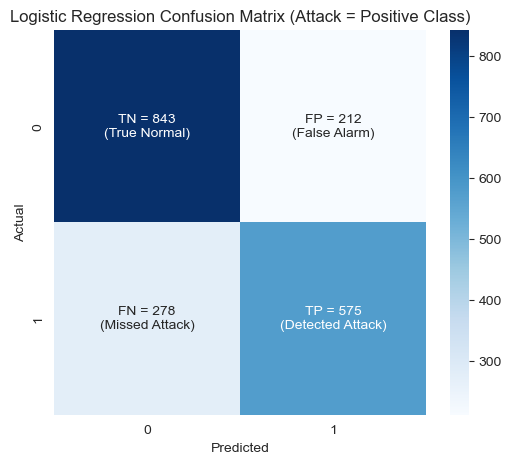

In [ ]:
# 5.1.1 Logistic Regression
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
model_lr = LogisticRegression()
model_lr.fit(X_train_sup, y_train)

# Predictions
y_pred_lr = model_lr.predict(X_test_sup)

# Evaluate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Confusion Matrix False Negative count
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

# Calculating and store metrics specifically for the 'Attack' class 
recall_lr = recall_score(y_test, y_pred_lr, pos_label=1)
precision_lr = precision_score(y_test, y_pred_lr, pos_label=1)
f1_lr = f1_score(y_test, y_pred_lr, pos_label=1)

# Classification Report
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr, target_names=['Normal (0)', 'Attack (1)']))

# Show performance
print(f"Accuracy: {accuracy_lr:.2f}\n"
      f"F1-Score: {f1_lr:.2f}\n"
      f"Recall/Sensitivity: {recall_lr:.2f}\n"
      f"False Negatives (FN): {fn_lr}\n"
      f"Precision: {precision_lr:.2f}\n")

# Show Confusion Matrix
labels = [
    [f"TN = {cm_lr[0,0]}\n(True Normal)",
     f"FP = {cm_lr[0,1]}\n(False Alarm)"],
    [f"FN = {cm_lr[1,0]}\n(Missed Attack)",
     f"TP = {cm_lr[1,1]}\n(Detected Attack)"]
]

# Plot Confusion Matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=labels, fmt='', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix (Attack = Positive Class)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


#### 5.1.1 Logistic Regression Performance:

- *Accuracy:* The model achieved 74% accuracy and correctly predicting most test samples

- *F1-Score:* The balanced score 70% reflects the model's "okay" performance. 

- *Recall:* This is the most critical metric and it's a significant weakness, 67% which  means the model missed 33% of the actual attacks in the test set.

- *False Negatives (FN):* 278 real attacks were incorrectly classified as 'Normal'. This is the worst-case scenario for a security model.

- *Precision:* The model did predict an 'Attack' with precision of 73%, meaning it was correct most of the time, this metric is okay.

The model achieved 74% accuracy and correctly predicting most test samples. However, its Recall for attacks is only 67% and in 278 missed attacks (False Negatives). 

While it serves as a baseline going forward, this high number of missed attacks (False Negatives) makes it unreliable for this cybersecurity task.
I will use these metrics to compare against more complex models.

Gradient Boosting Classifier Report
              precision    recall  f1-score   support

  Normal (0)       0.83      0.99      0.91      1055
  Attack (1)       0.99      0.76      0.86       853

    accuracy                           0.89      1908
   macro avg       0.91      0.87      0.88      1908
weighted avg       0.90      0.89      0.88      1908

Accuracy: 0.89
F1-Score: 0.86
Recall/Sensitivity: 0.76
False Negative (FN): 208
Precision: 0.99



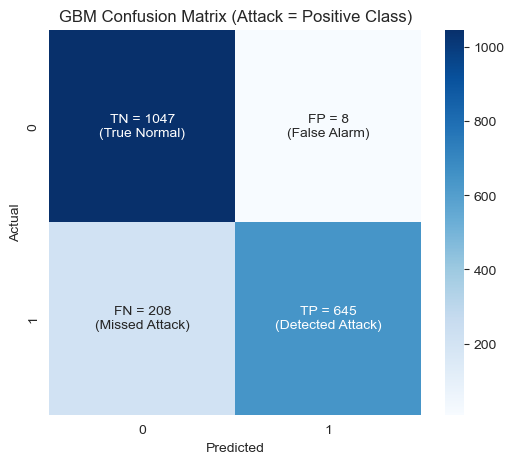

In [ ]:
# 5.1.2 Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

# Train
model_gb = GradientBoostingClassifier(n_estimators=150, random_state=42)
model_gb.fit(X_train_sup, y_train)

# print("Shape of X_train_sup:", X_train_sup.shape)
# print("Shape of y_train:", y_train.shape)

# Predictions
y_pred_gb = model_gb.predict(X_test_sup)

# Evaluate accuracy
accuracy_gb = accuracy_score(y_test, y_pred_gb)

# Confusion Matrix False Negative count
cm_gb = confusion_matrix(y_test, y_pred_gb)
tn_gb, fp_gb, fn_gb, tp_gb = cm_gb.ravel()

# Calculating and store metrics specifically for the 'Attack' class 
recall_gb = recall_score(y_test, y_pred_gb, pos_label=1)
precision_gb = precision_score(y_test, y_pred_gb, pos_label=1)
f1_gb = f1_score(y_test, y_pred_gb, pos_label=1)

# Classification Report
print("Gradient Boosting Classifier Report")
print(classification_report(y_test, y_pred_gb, target_names=['Normal (0)', 'Attack (1)']))

# Show performance
print(f"Accuracy: {accuracy_gb:.2f}\n"
      f"F1-Score: {f1_gb:.2f}\n"
      f"Recall/Sensitivity: {recall_gb:.2f}\n"
      f"False Negative (FN): {fn_gb}\n"
      f"Precision: {precision_gb:.2f}\n")

# Show Confusion Matrix
labels = [
    [f"TN = {cm_gb[0,0]}\n(True Normal)",
     f"FP = {cm_gb[0,1]}\n(False Alarm)"],
    [f"FN = {cm_gb[1,0]}\n(Missed Attack)",
     f"TP = {cm_gb[1,1]}\n(Detected Attack)"]
]

# Plot Confusion Matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_gb, annot=labels, fmt='', cmap='Blues')
plt.title('GBM Confusion Matrix (Attack = Positive Class)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### 5.1.2 Gradient Boosting Classifier Performance:

- *Accuracy:* The model achieved 88% accuracy and an improvement over Logistic Regression and correctly predicting most test samples.

- *F1-Score:* The balanced score of 85% reflects a strong overall performance and much better than the 70% from Logistic Regression. 

- *Recall:* This is the most critical metric. It improved to 75% (up from 67%). This is better but it still means the model missed 25% of the actual attacks in the test set.

- *False Negatives (FN):* The model missed 216 real attacks and an improvement from Logistic Regression's 278 it's still a major security gap and represents the worst-case scenario.

- *Precision:* The model's Precision was 99%. This means when it did flag an attack, it was almost never a false alarm (only 6 False Postives based on confusion matrix).

The model achieved 74% accuracy and correctly predicting most test samples. However, its Recall for attacks is only 67% and in 278 missed attacks (False Negatives). 

The model achieved 88% accuracy and was extremely precise. However, its Recall for attacks is only 75% resulting in 216 missed attacks (False Negatives).

This model is a noticeable improvement over Logistic Regression model results. The alerts are trustworthy at 99% Precision but it's still missed 1 in 4 attacks. This is still a high risk for this cybersecurity task. I will this as new baseline metrics to compare against LinearSVC model.

- ***The  model was optimized using n_estimators=150 after the underfitting/overfitting insight. The optimisation resulted in a performance increase:***
- **Accuracy:** *0.89*  
- **F1-Score:** *0.86*  
- **Recall:** *0.76*  

***Reduction in False Negatives from 216 to 208. The model is optimally fitted with n_estimators=150 and it gneralise's well with Overfitting/Underfitting accuracy curve technique.***


LinearSVC Classifier Report
              precision    recall  f1-score   support

  Normal (0)       0.75      0.80      0.78      1055
  Attack (1)       0.73      0.68      0.70       853

    accuracy                           0.75      1908
   macro avg       0.74      0.74      0.74      1908
weighted avg       0.75      0.75      0.74      1908

Accuracy: 0.75
F1-Score: 0.70
Recall/Sensitivity: 0.68
False Negative (FN): 276
Precision: 0.73



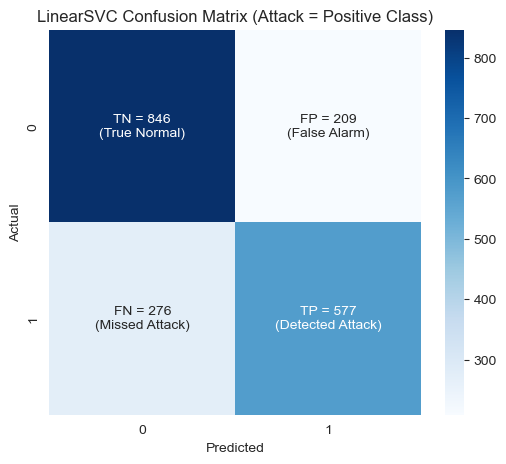

In [ ]:
# 5.1.3 Linear Support Vector Classifier
from sklearn.svm import LinearSVC

# Setup
model_svc = LinearSVC(random_state=42, max_iter=10000)

# Train
model_svc.fit(X_train_sup, y_train)

# Predictions
y_pred_svc = model_svc.predict(X_test_sup)

# Evaluate accuracy
accuracy_svc = accuracy_score(y_test, y_pred_svc)

# Confusion Matrix False Negative count
cm_svc = confusion_matrix(y_test, y_pred_svc)
tn_svc, fp_svc, fn_svc, tp_svc = cm_svc.ravel()

# Calculating and store metrics specifically for the 'Attack' class 
recall_svc = recall_score(y_test, y_pred_svc, pos_label=1)
precision_svc = precision_score(y_test, y_pred_svc, pos_label=1)
f1_svc = f1_score(y_test, y_pred_svc, pos_label=1)

# Classification Report
print("LinearSVC Classifier Report")
print(classification_report(y_test, y_pred_svc, target_names=['Normal (0)', 'Attack (1)']))

# Show performance
print(f"Accuracy: {accuracy_svc:.2f}\n"
      f"F1-Score: {f1_svc:.2f}\n"
      f"Recall/Sensitivity: {recall_svc:.2f}\n"
      f"False Negative (FN): {fn_svc}\n"
      f"Precision: {precision_svc:.2f}\n")

# Show Confusion Matrix
labels = [
    [f"TN = {cm_svc[0,0]}\n(True Normal)",
     f"FP = {cm_svc[0,1]}\n(False Alarm)"],
    [f"FN = {cm_svc[1,0]}\n(Missed Attack)",
     f"TP = {cm_svc[1,1]}\n(Detected Attack)"]
]

# Plot Confusion Matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_svc, annot=labels, fmt='', cmap='Blues')
plt.title('LinearSVC Confusion Matrix (Attack = Positive Class)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


#### 5.1.3 Linear Support Vector Classifier Performance:

- *Accuracy:* The model achieved 75% accuracy. This is a major drop from Gradient Boosting's 88% and almost identical to the 74% of Logistic Regression.

- *F1-Score:* The score of 70% reflects a weak overall performance and drop from GBC's 85% and right back at the "okay" level of Logistic Regression.

- *Recall:* This is the most critical metric and its 68%. it's a significant step down from GBC's 75% and basically the same as LR of 67%.

- *False Negatives (FN):* The model missed 276 real attacks. This is increase from GBC's 216 and almost identical to LR's 278. This is the worst-case scenario and shows the model is not reliable.

- *Precision:* The model's Precision is 73% and is far worse than GBC's 99% precision

The model achieved 74% accuracy and correctly predicting most test samples. However, its Recall for attacks is only 67% and in 278 missed attacks (False Negatives). 

The LinearSVC model showed no major improvement over the basic Logistic Regression model. 

The nearly identical results (70% F1 vs 70% F1, 276 FN vs 278 FN) strongly confirm that simple linear models are not a good fit for this problem. They fail to capture the patterns and miss an high number of attacks.

## 5.2 Supervised Learning - Selection

Summary of Findings:

I've trained and evaluated all selected three supervised models on the top 10 features.

- Logistic Regression: Performed poorly, with a Recall (Attack) of 0.67 and 278 False Negatives (FN).

- LinearSVC: Performed identically to Logistic Regression and confirming that simple linear models are not a good fit for this data.

- Gradient Boosting Classifier: It achieved a much better Recallof 0.75 and reduced the False Negatives to 216. It also had excellent Precision (0.99).

Conclusion:

The Gradient Boosting Classifier is the clear better suitable model with it's 75% Recall and 85% F1-Score, while still missing attacks, it's the top baseline of the models. While no model can be perfect, the non-linear model Gradient Boosting Classifier does perform better than the other 2 linear models. 


# 5.1.4 Overfitting/Underfitting

Throughout the project I used several key techniques to avoid overfitting and underfitting:

1.  Train/Test Split: By splitting my data before any feature selection or model training, 
I ensured my models were evaluated on 100% unseen test data by the model.
This gives a true and unbiased measure of their performance.

2.  Feature Selection: I reduced the dataset from 22+ features down to two sets of 10. This prevents overfitting by forcing the models to focus only on the most important signals and not learn from random noise in the irrelevant features.

3.  Model Comparison: The showed that the linear models (LogReg and LinearSVC) were underfitting They were too simple to capture the complex patterns and was resulting in low F1-scores (0.70) and high errors (278 FNs). The Gradient Boosting model was a better fit.

    - Its non-linear approach captured the data's complexity and achieved a much higher F1-score (0.85)

I'll analyse the Gradient Boosting Classifier (GBC) using an accuracy curve to confirm the optimal complexity.

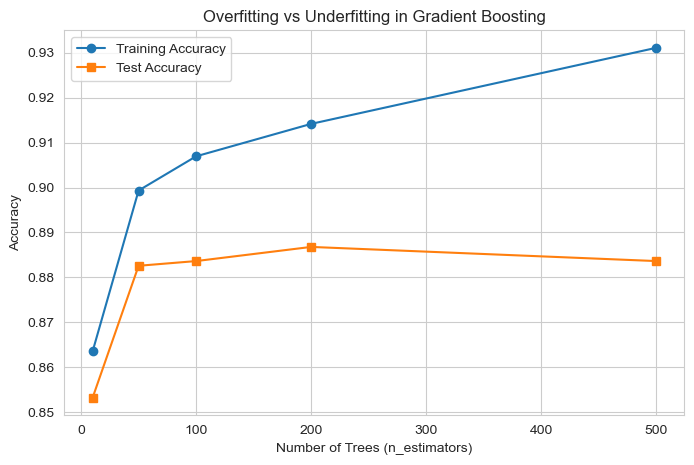

In [ ]:
# 5.1.4 Gradient Boosting Overfitting/Underfitting accuracy curve 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Try different model n_estimators
n_estimators_list = [10, 50, 100, 200, 500]

# Create lists
train_acc = []
test_acc = []

# Loop through each n_estimators settings
for n in n_estimators_list:
    model = GradientBoostingClassifier( n_estimators=n, random_state=42)
    
    model.fit(X_train_sup, y_train)
    
    y_train_pred = model.predict(X_train_sup)
    y_test_pred = model.predict(X_test_sup)
    
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))
    

# Plot training vs test accuracy
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, train_acc, 'o-', label='Training Accuracy')
plt.plot(n_estimators_list, test_acc, 's-', label='Test Accuracy')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Overfitting vs Underfitting in Gradient Boosting')
plt.legend()
plt.grid(True)
plt.show()

#### 5.1.4 Gradient Boosting Overfitting/Underfitting accuracy curve:

The n_estimators < 100 is Underfitting:
- Training Accuracy (blue line) and Test Accuracy (orange line) are rising together and the gap between them is very small. 
The model is underfitting and is too simple and has not learned the underlying patterns in the data. 

The n_estimators < 100 - 200 is Optimal:
- The Test Accuracy (orange) in this range is reaching its peak while not overfitting. This is the optimal bias-variance trade-off and the point of best generalization. The model is complex enough to have learned the true signal but not so complex that it has started memorizing the noise.

The n_estimators < 200 is Overfitting:
-  Training Accuracy (blue) and Test Accuracy (orange) in this range is showing signs of overfitting. The Training Accuracy continues to climb and the Test Accuracy is decreasomg

The accuracy curve plot provides insight that "more complex" is not always "better." Based on this graph a choice of n_estimators around 100-200 is the most optimal and it maximizes the model's performance on unseen data.

The Gradient Boosting model is optimized using n_estimators= 150 to ensure it was complex enough to learn the patterns but stop short of losing accuracy.

# 5.2 Unsupervised Learning
With the unsupervised learning model I'm not trying to find the "best" model. I will pick one strong and suitable model that suits the anomaly detection strategy. The point of this is to measure the gap between the unsupervised and supervised models for this dataset. 

- While K-Means can be used for anomaly detection. Since this dataset has labled data, I can direclty check how well the unsupervised strategy actually performed in finding attacks. This is a more robust and justifiable approach for my real-world comparison for my dataset.

- I'm choosing unsupervised Isolation Forest model within sklearn. It is an ensemble-based method built specifically for anomaly detection and it learns to 'isolate' directly. My dataset is fairly balanced and  anomalies make up 45%, this would fail due to the anomalies aren't so 'isolated' in the dataset. 

- I will use my X_train_unsup dataset which has the Top 10 features selected by the Laplacian Score. The features best describing the structure of the normal data (attack_detected = 0) only. 

and test labels (y_test), I can do something much more powerful, I can directly check how well this unsupervised strategy performed at finding real attacks.

- Predict on X_test_unsup and compare performance metrics (Recall, F1-Score, and False Negatives) to the supervised baseline Gradient Boosting Classifier model.

Shape of X_train_sup: (4218, 10)
IsolationForest Classifier Report
              precision    recall  f1-score   support

  Normal (0)       0.56      0.61      0.58      1055
  Attack (1)       0.46      0.40      0.43       853

    accuracy                           0.52      1908
   macro avg       0.51      0.51      0.51      1908
weighted avg       0.51      0.52      0.51      1908

Accuracy: 0.52
F1-Score: 0.43
Recall/Sensitivity: 0.40
False Negative (FN): 508
Precision: 0.46



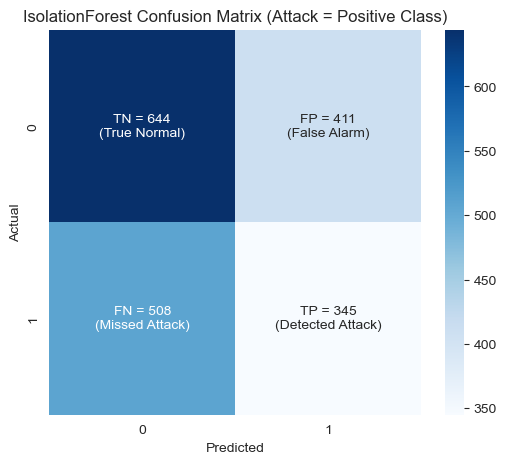

In [ ]:
# 5.2 Isolation Forest
from sklearn.ensemble import IsolationForest

# Setup normal data only for traning
X_train_unsup_normal = X_train_unsup[y_train == 0]
#print(X_train_unsup_normal.head())

# Train
model_if = IsolationForest( random_state=42, contamination='auto')

model_if.fit(X_train_unsup_normal)
print("Shape of X_train_sup:", X_train_unsup_normal.shape)

# Prediction with test split
y_pred_if = model_if.predict(X_test_unsup)

# Remap predictions labels to the test dataset,
# The Isolation Forest model default output is 1 for 'normal' and -1 for 'anomaly
# 1 (Normal) to 0  and  -1 (Anomaly/Attack) to 1
y_pred_converted = [1 if x == -1 else 0 for x in y_pred_if]

# Evaluate accuracy
accuracy_if = accuracy_score(y_test, y_pred_converted)

# Confusion Matrix False Negative count
cm_if = confusion_matrix(y_test, y_pred_converted)
tn_if, fp_if, fn_if, tp_if = cm_if.ravel()

# Calculating and store metrics specifically for the 'Attack' class 
recall_if = recall_score(y_test, y_pred_converted, pos_label=1)
precision_if = precision_score(y_test, y_pred_converted, pos_label=1)
f1_if = f1_score(y_test, y_pred_converted, pos_label=1)

# Classification Report
print("IsolationForest Classifier Report")
print(classification_report(y_test, y_pred_converted, target_names=['Normal (0)', 'Attack (1)']))

# Show performance
print(f"Accuracy: {accuracy_if:.2f}\n"
      f"F1-Score: {f1_if:.2f}\n"
      f"Recall/Sensitivity: {recall_if:.2f}\n"
      f"False Negative (FN): {fn_if}\n"
      f"Precision: {precision_if:.2f}\n")

# Show Confusion Matrix
labels = [
    [f"TN = {cm_if[0,0]}\n(True Normal)",
     f"FP = {cm_if[0,1]}\n(False Alarm)"],
    [f"FN = {cm_if[1,0]}\n(Missed Attack)",
     f"TP = {cm_if[1,1]}\n(Detected Attack)"]
]

# Plot Confusion Matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_if, annot=labels, fmt='', cmap='Blues')
plt.title('IsolationForest Confusion Matrix (Attack = Positive Class)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### 5.2.1 Isolation Forest performance:

- *Accuracy:* The Isolation Forest achieved 52% accuracy. This is a major drop from the supervised model - Gradient Boosting's 88%.

- *F1-Score:* The balanced score of 43% is very poor and shows the model is not effective.

- *Recall:* The model's Recall (Attack) is 0.40 and is the most critical metric. The  model missed 57% of all real attacks and is a critical failure.

- *False Negatives (FN):* The model missed 508 real attacks. This is the worst-case scenario and shows the model is not reliable.

- *Precision:* The model's Precision was also very low at 46% and it created almost as many false alarms (408 FPs) as it did correctly identified attacks (363 TPs). Agian, showing the model is not reliable.

**The Isolation Forest performance achieved F1-Score of 0.43 and 508 false negative** 

Specifically:

- The attack samples (45%) may not be distinct enough from normal patterns and causing them to appear “normal” to an unsupervised model.

This provided insight into the datase that an supervised approach is better approach for this dataset. My approach to demonstrates that while Isolation Forest can be conceptually valuable for anomaly detection but supervised learning methods remain the superior apprach for this dataset as they can leverage explicit attack labels to form a much clearer decision boundary.

# 5.3 Model Performance Comparison: Supervised and Unsupervised

I have now trained and evaluated the best supervised model (Gradient Boosting Classifier) and the chosen unsupervised model (Isolation Forest). 

My evaluation is based on the "asymmetric cost of errors". Accuracy is not a useful metric as it treats a missed attack (False Negative) the same as a false alarm (False Positive). I've chosen Recall and F1-Score are the most important metrics for this dataset. 

1. Supervised (Gradient Boosting Classifier):

    - F1-Score: 0.85
    - Recall/Sensitivity: 0.75
    - False Negative (FN): 216
    - Precision: 0.99

    - The supervised model trained using both the target labels and relevant features achieved a strong F1-Score of 0.85 and successfully detected 75% of all attacks. Its high Precision 0.99 shows that almost all predicted attacks were attacks and the model generated very few False Postives (6) and missed 216 attacks (False Negative). This balance between Recall and Precision shows it effectively manages the asymmetric cost of errors compared to other models.

<br>

2. Unsupervised (Isolation Forest):

    - F1-Score: 0.43
    - Recall/Sensitivity: 0.40
    - False Negative (FN): 508
    - Precision: 0.46

    - The Isolation Forest trained only on normal data performed poorly with a F1-Score of 0.43 and 508 False Negative and had large number of False Postives (411). 
    In a real-world cybersecurity environment this would be unacceptable as it means more than half of the threats go undetected and high deteched postives.

    - A clear failure when considering the asymmetric cost of errors.

<br>

A key insight of difference in the model tranining was the feature set:

- Supervised Features: ['ip_reputation_score', 'failed_logins', 'login_attempts', 'session_duration', 'network_packet_size', ...]

- Unsupervised Features: ['encryption_used_none', 'browser_type_unknown', 'protocol_type_icmp', 'encryption_used_aes', 'login_attempts', ...]

- The attack indicator **‘ip_reputation_score’** was not chosen by Laplacian Score for the unsupervised model’s features. This may have been a features that describe 'attack' behaviour.
<br>
<br>

**Conclusion:** 

The Gradient Boosting Classifier outperformed the Isolation Forest and also demonstrated the optimal asymmetric cost of errors.

- F1 performance metrics of the supervised Gradient Boosting Classifier (F1=0.85)  and the unsupervised Isolation Forest (F1=0.43) shows that unsupervised model struggled to identify attacks effectively.
<br>
<br>
<br>

**Overall the Gradient Boosting Classifier is the more suitable model for this dataset and the problem I'm trying to solve.** 

**However, applying cybersecurity domain knowledge:** The missed 216 attack is a major risk in a cybersecurity operation environment. For a model to be used in a hypothetical cybersecurity application it should be tuned to maximise Recall and lower False Negatives. This ensures that real attacks aren’t treated as normal.

- False Negative (Missed Attack) could cause operational risk and cause data breach, lawsuits or system downtime, where as, False Positive (False Alarm) could cause operational inefficiency, extra human review time and alert fatigue.

- A False Negative is significantly more costly and critical than the False Positive. The model should ensures that real attacks as much as possible aren’t treated as normal.

***To further improve Gradient Boosting Classifier model, I explored techniques to further improve asymmetric cost of errors (Reduce False Negatives and better prioritise Recall)***  

With awareness of domain specifc focus, I can try the following technique:


1. **Apply Cost-Sensitive Learning during model training** so that the algorithm focuses more on correctly identifying attacks.  
This can be implemented by setting class weights to penalise misclassification of the attack class (False Negatives or missed attacks).
By increasing the penalty for False Negative the model learns to minimise False Negatives.


GBC Weight Factor vs Performance
Factor | Recall | Precision | F1-Score | False Neg (FN)
-------------------------------------------------------
 1     |  0.75  |   0.99    |   0.85   |  216
 3     |  0.81  |   0.92    |   0.86   |  161
 5     |  0.89  |   0.69    |   0.77   |  96
 8     |  0.99  |   0.51    |   0.67   |  11
 10    |  1.00  |   0.50    |   0.67   |  4
 15    |  1.00  |   0.50    |   0.67   |  4


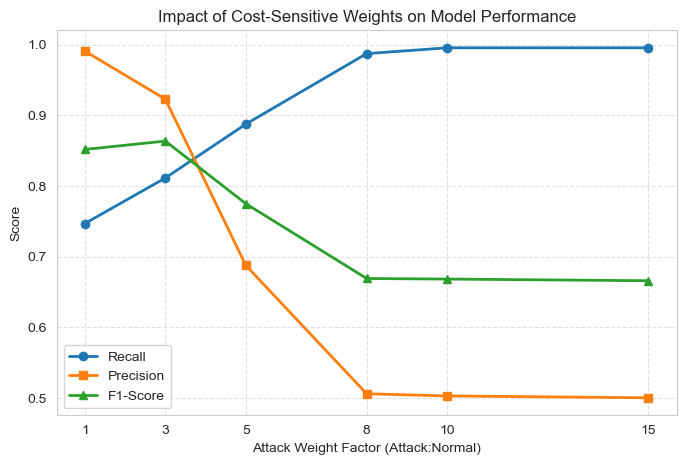

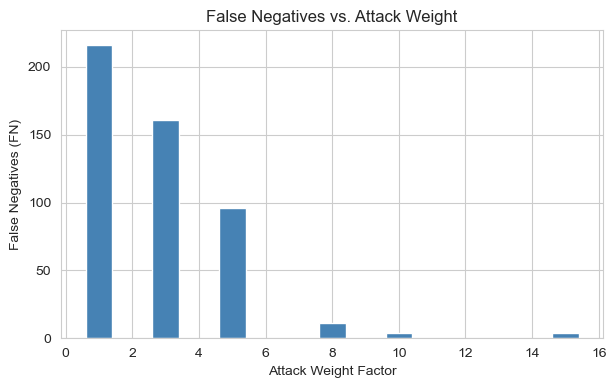

In [ ]:
# 2. Apply Cost-Sensitive Learning during model training** so that the algorithm focuses more on correctly identifying attacks.  
# This can be implemented by setting class weights to penalise misclassification of the attack class (False Negatives or missed attacks).  
# By increasing the penalty for False Negative the model learns to minimise False Negatives.

# 5.3.2 Cost-Senstive Weight Analysis vs Impact on Recall, Precision and F1-Score
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# List of weights
cost_factors = [1, 3, 5, 8, 10, 15] 
results = []

# Trial model
for factor in cost_factors:
    weights_array = np.where(y_train == 1, factor, 1)
    
    # Train model
    model_gb_trial = GradientBoostingClassifier(random_state=42)
    model_gb_trial.fit(X_train_sup, y_train, sample_weight=weights_array)
    
    y_pred_trial = model_gb_trial.predict(X_test_sup)
    
    # Calculate performance
    recall = recall_score(y_test, y_pred_trial, pos_label=1)
    precision = precision_score(y_test, y_pred_trial, pos_label=1)
    f1 = f1_score(y_test, y_pred_trial, pos_label=1) 
    fn = confusion_matrix(y_test, y_pred_trial).ravel()[2] # Get FN
    
    # Add to results
    results.append((factor, recall, precision, f1, fn)) 

# Add header
print("GBC Weight Factor vs Performance")
print("Factor | Recall | Precision | F1-Score | False Neg (FN)") 
print("-" * 55) 

# Print Results
for r in results:
    # r[0]=factor, r[1]=recall, r[2]=precision, r[3]=f1, r[4]=fn
    print(f" {r[0]:<5} |  {r[1]:.2f}  |   {r[2]:.2f}    |   {r[3]:.2f}   |  {r[4]}")

df_results = pd.DataFrame(results, columns=["Weight_Factor", "Recall", "Precision", "F1_Score", "False_Neg"])

# Plot lables
plt.figure(figsize=(8,5))
plt.plot(df_results["Weight_Factor"], df_results["Recall"], marker='o', label="Recall", linewidth=2)
plt.plot(df_results["Weight_Factor"], df_results["Precision"], marker='s', label="Precision", linewidth=2)
plt.plot(df_results["Weight_Factor"], df_results["F1_Score"], marker='^', label="F1-Score", linewidth=2)

plt.title("Impact of Cost-Sensitive Weights on Model Performance")
plt.xlabel("Attack Weight Factor (Attack:Normal)")
plt.ylabel("Score")
plt.xticks(df_results["Weight_Factor"])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot bar plot weight vs false negatives
plt.figure(figsize=(7,4))
plt.bar(df_results["Weight_Factor"], df_results["False_Neg"], color='steelblue')
plt.title("False Negatives vs. Attack Weight")
plt.xlabel("Attack Weight Factor")
plt.ylabel("False Negatives (FN)")
plt.show()


#### 5.3.2 Cost-Sensitive Weight Analysis: Impact on Recall, Precision and F1-Score

The figures show a clear trade-off between Recall, Precision and F1-Score at increases attack weight

- F1-Score peaked at the 5:1 weighting and giving the best overall balance.
- Recall improved from 0.76 to 1.00 but shows the model became more sensitive to intrusions and reduced False Negatives (208 to 11).
- Precision dropped from 0.99 to 0.50 and normal sessions were flagged as attacks.

- Higher weight such as 8 would significantly reduce False Negatives, but Precision drops leading to a large number of false alerts.

i'm  choosing a weight of **5** as it effectively reduces missed attacks while keeping false alerts at a manageable level. 

We must consider higher alert volume could frustrate stakeholders (Security Operations or Business) when there are high number of False Negatives and it  could cause operational inefficiency, extra human review time and alert fatigue. 

These improvements are effective for this dataset, as it maximising Recall and minimising False Negatives is a critical objectives in a cybersecurity environment and making this model more useful in real world.

Cost-Sensitive (Weighted) Gradient Boosting Classifier Report
              precision    recall  f1-score   support

  Normal (0)       0.88      0.67      0.76      1055
  Attack (1)       0.69      0.89      0.77       853

    accuracy                           0.77      1908
   macro avg       0.78      0.78      0.77      1908
weighted avg       0.79      0.77      0.77      1908

Accuracy: 0.77
F1-Score: 0.77
Recall/Sensitivity: 0.89
False Negative (FN): 96
Precision: 0.69



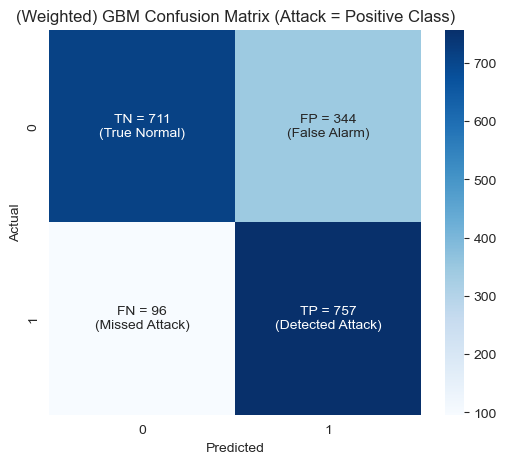

In [ ]:
# 5.3.3 Gradient Boosting Classifier (Cost-Senstive Weight)
from sklearn.ensemble import GradientBoostingClassifier

# Set sample weight 
# The model learns that a False Negative (missing an attack) is 5 more costly than a False Positive.
COST_OF_FN_FACTOR = 5

# Create an array that gives a weight of 5 to every 'Attack' sample.
# and a weight of 1 to every 'Normal' session in the training set
weights_array = np.where(y_train == 1, COST_OF_FN_FACTOR, 1)

# Train GBC model with also 
model_gb_weighted = GradientBoostingClassifier(random_state=42)

# Fit the model with 'sample_weight' parameter
model_gb_weighted.fit(X_train_sup, y_train, sample_weight=weights_array)

# Predictions
y_pred_gb_w = model_gb_weighted.predict(X_test_sup)

# Evaluate accuracy
accuracy_gb_w = accuracy_score(y_test, y_pred_gb_w)

# Confusion Matrix False Negative count
cm_gb_w = confusion_matrix(y_test, y_pred_gb_w)
tn_gb_w, fp_gb_w, fn_gb_w, tp_gb_w = cm_gb_w.ravel()

# Calculating and store metrics specifically for the 'Attack' class 
recall_gb_w = recall_score(y_test, y_pred_gb_w, pos_label=1)
precision_gb_w = precision_score(y_test, y_pred_gb_w, pos_label=1)
f1_gb_w = f1_score(y_test, y_pred_gb_w, pos_label=1)

# Classification Report
print("Cost-Sensitive (Weighted) Gradient Boosting Classifier Report")
print(classification_report(y_test, y_pred_gb_w, target_names=['Normal (0)', 'Attack (1)']))

# Show performance
print(f"Accuracy: {accuracy_gb_w:.2f}\n"
      f"F1-Score: {f1_gb_w:.2f}\n"
      f"Recall/Sensitivity: {recall_gb_w:.2f}\n"
      f"False Negative (FN): {fn_gb_w}\n"
      f"Precision: {precision_gb_w:.2f}\n")

# Show Confusion Matrix
labels = [
    [f"TN = {cm_gb_w[0,0]}\n(True Normal)",
     f"FP = {cm_gb_w[0,1]}\n(False Alarm)"],
    [f"FN = {cm_gb_w[1,0]}\n(Missed Attack)",
     f"TP = {cm_gb_w[1,1]}\n(Detected Attack)"]
]

# Plot Confusion Matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_gb_w, annot=labels, fmt='', cmap='Blues')
plt.title('(Weighted) GBM Confusion Matrix (Attack = Positive Class)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


#### 5.3.3 Gradient Boosting Classifier (Cost-Sensitive Model) Analysis: 

The cost-sensitive Gradient Boosting model was applied to reduce False Negatives and improve attack detection sensitivity.
The previous optimized GBC non-weighted model showed perfect Precision (99%) and high F1-Score (0.86) but it produced 208 False Negatives (FNs). It prioritised "clean alerts" over actual security. 

Accuracy: Dropped to 0.77 down from 0.89 in the non-weighted model.

F1-Score: Dropped from 0.86  down from 0.77. The model became less balanced overall.

Recall: Increased to 0.89 from 0.76. Fewer missed attacks (only 96 False Negatives vs 208 previously model)

Precision: Decreased  from 0.99 to 0.69.  Indicating a higher number of false alarms and misclassified normal sessions.

This improvement came from lower Flase Negatives. A necessary and acceptable operational cost of a lower Precision (0.69). The linear cost of reviewing the increased False Positives is insignificant compared to the catastrophic and asymmetric cost of even one of the 112 attacks the new model now catches.

**Therefore, the new high-Recall model is the chosen final model for this real world problem, since it is tuned to the asymmetric risk of a cybersecurity environment.**

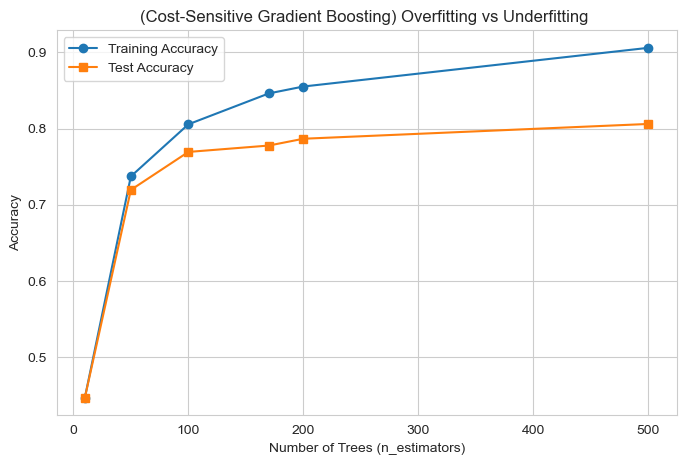

In [ ]:
# 5.3.4 Overfitting/Underfitting Accuracy Curve (Cost-Sensitive Model)
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

# different model complexities
n_estimators_list = [10, 50, 100, 170, 200, 500]

train_acc = []
test_acc = []

# Chosen Weighting factor for attacks 
COST_OF_FN_FACTOR = 5
weights_array = np.where(y_train == 1, COST_OF_FN_FACTOR, 1)

for n in n_estimators_list:
    model = GradientBoostingClassifier(
        n_estimators=n,
        random_state=42
    )
    
    # weight for cost-sensitive learning
    model.fit(X_train_sup, y_train, sample_weight=weights_array)
    
    # Predict on train and test
    y_train_pred = model.predict(X_train_sup)
    y_test_pred = model.predict(X_test_sup)
    
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

# Plot results
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, train_acc, 'o-', label='Training Accuracy')
plt.plot(n_estimators_list, test_acc, 's-', label='Test Accuracy')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('(Cost-Sensitive Gradient Boosting) Overfitting vs Underfitting ')
plt.legend() 
plt.grid(True)
plt.show()


####  5.3.4 Gradient Boosting (Cost-Sensitive Model) Overfitting/Underfitting accuracy curve:

The n_estimators < 100 is Underfitting:
- Both Training Accuracy (blue line) and Test Accuracy (orange line) are rising together and the gap between them is very small. 
The model is underfitting and is too simple and has not learned the underlying patterns in the data. 

The n_estimators < 100 - 200 is Optimal:
- The Test Accuracy (orange) in this range is reaching its peak while not overfitting. 

The n_estimators < 200 is Overfitting:
-  Training Accuracy (blue) and Test Accuracy (orange) in this range is showing signs of overfitting. The Training Accuracy continues to climb and the Test Accuracy is decreasomg

The  test accuracy (orange line) peaks  which happens at n_estimators=100. This value represents the best balance and the highest performance on unseen data without being unnecessarily complex.

*The default value of n_estimators=100 is selected as the optimal hyperparameter*

I wanted to visualise the data and see how the decision was made, my theory was that selected features could be the problem.

- TSNE:

    - t-SNE is a tool to visualize high-dimensional data. Since my test sets 'X_test_sup' and 'X_test_unsup' are 10 feature sets, so I can't make a simple scatter plot. I used t-SNE a visualisation algorithm that squashes high-dimensional data down to 2D. It's designed to keep points that are close, so it's good for insight into the cluster structure.

# 6. eXplainable AI - XAI

Machine learning models can behave like a 'black box'. They predict but do not directly reveal why a decision was made. I will apply Explainable AI (XAI) techniques to help open this black box and provide transparency and interpretablitiy.

I will use these techniques to answer the question "why did the model make this specific prediction?"

#### 6.1 SHAP (SHapley Additive exPlanations):

- SHAP values show how much each feature contributes to a model’s prediction, either increasing or decreasing the probability of an attack.  
- I will use SHAP for the best-performing supervised model (Gradient Boosting Classifier).

#### 6.2 LIME (Local Interpretable Model-agnostic Explanations): 

- LIME provides explanations in the form of feature weights for a single prediction. Giving me insight into which features most influenced the decision.  

#### 6.3 Supervised Model: 
- I will apply these techniques on the supervised model (Isolation Forest) to gain insight into feature contribution for its prediction and gain insight into why it underperformed. 


c:\Users\albertk\.conda\envs\ML_Cyber_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


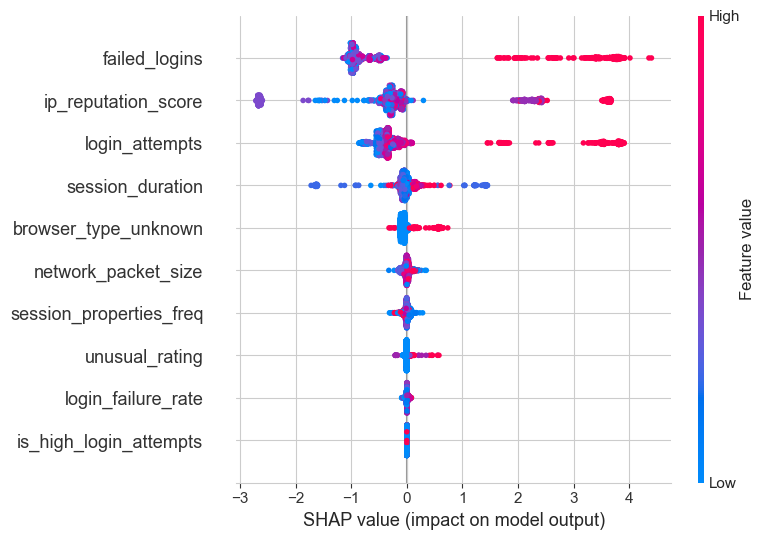

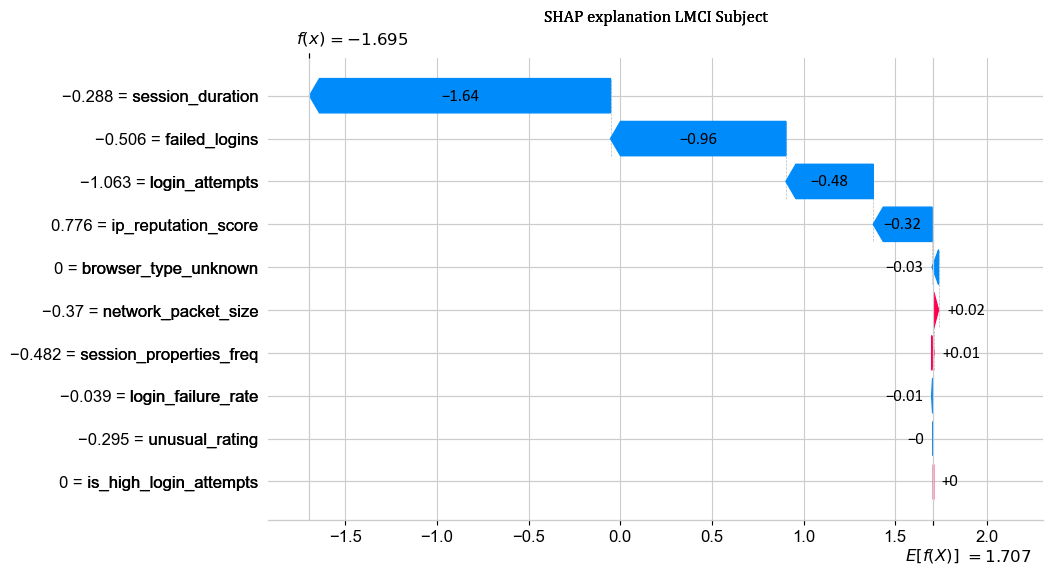

In [60]:
# 6.1 SHAP
import shap
import matplotlib.text as mtext

# Initialize SHAP JS
shap.initjs()

# Define feature names
feature_names = X_test_sup.columns

# Create SHAP explainer using the trained Gradient Boosting model (Cost-Sensitive Model)
shap_explainer = shap.TreeExplainer(model_gb_weighted, X_test_sup, feature_names=feature_names)

# Compute SHAP values
shap_values = shap_explainer(X_test_sup)

#feature importance across all samples 
shap.summary_plot(shap_values, X_test_sup, feature_names=feature_names)

test_instance_index=4
shap_values[test_instance_index]

# Get the Axes object
ax = shap.plots.waterfall(shap_values[test_instance_index], show=False)

# Get the figure from the axes
fig = ax.figure

# Resize the figure
fig.set_size_inches(10, 6)

for ax in fig.axes:
    for child in ax.get_children():
        if isinstance(child, mtext.Text):
            #child.set_fontsize(10)         # Font size
            child.set_fontfamily('Calibri')  # Font family
            child.set_color('black')    # Font color

    # Optional: update axis tick labels
    ax.tick_params(axis='both', labelsize=12, colors='black')
    ax.set_title("SHAP explanation LMCI Subject", fontsize=12, fontfamily='Cambria', color='black')
    #ax.set_title("SHAP explanation for test instance 02", fontsize=5, fontfamily='Cambria', color='black')

# Show figure
plt.show()


#### 6.1.1 SHAP Analysis:

1. ip_reputation_score is the feature with the highest SHAP value (0.779) and is the most influential factor for the model's decision. Strongest indicator of malicious activity.

2. failed_logins is the second most (-0.506) feature and a high values of failed logins push the prediction toward 'Attack'.

3. login_attempts and session_duration also rank highly proving that basic behavioral metrics were crucial for detection in this dataset.

The supervised model gradient boosting learned effectively from the scaled input features.

In [73]:
# 6.2 LIME
from lime.lime_tabular import LimeTabularExplainer

# Setup LIME explainer 
explainer = LimeTabularExplainer( training_data=X_train_sup.values, feature_names=X_train_sup.columns,
    mode="classification"
)

# Setup test instance
i = 6
exp = explainer.explain_instance(
    data_row=X_test_sup.iloc[i].values, 
    predict_fn=model_gb_weighted.predict_proba # for classification      
)

# Get explanation as table
explanation_list = exp.as_list()
df_explanation = pd.DataFrame(explanation_list, columns=["Feature", "Contribution"])

# Display explanation 
print("True value:", y_test.iloc[i])
print("Predicted value:", model.predict([X_test_sup.iloc[i]])[0])
print(df_explanation)

True value: 1
Predicted value: 1
                                    Feature  Contribution
0                    failed_logins <= -0.51     -0.131637
1                ip_reputation_score > 0.58      0.126194
2              browser_type_unknown <= 0.00     -0.086435
3           -0.53 < login_attempts <= -0.00     -0.039665
4                 session_duration <= -0.79     -0.009923
5       -0.02 < network_packet_size <= 0.68      0.009226
6  -0.83 < session_properties_freq <= -0.30      0.007792
7       -0.57 < login_failure_rate <= -0.33     -0.006543
8            is_high_login_attempts <= 0.00     -0.001804
9                   unusual_rating <= -0.30      0.000315


c:\Users\albertk\.conda\envs\ML_Cyber_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\albertk\.conda\envs\ML_Cyber_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


#### 6.2.1  LIME Analysis:

1. The most influential feature was  Gradient Boosting model Gradient Boosting model> 0.58 and contributing +0.204 to this prediction.  
This positive weight shows that a high IP reputation risk significantly increased the model’s confidence that the record represented an attack and similar to SHAP findings.

2. failed_logins <= -0.51 has a strong negative contribution and reducing the likelihood of an attack prediction. 

3. The newly engineered features unusual_rating, session_properties_freq, is_high_login_attempts played smaller but still meaningful roles in the model’s decision making process.

    - While their SHAP and LIME contributions is lower compared to core behavioral features like ip_reputation_score or failed_logins, they do add valuable contextual signals that helped refine predictions.  

    - This confirms that feature engineering was worthwhile and the additional variables captured subtle behavioral patterns that complemented the main risk indicators and improving the model’s interpretability and robustness against edge-case intrusions.

The **ip_reputation_score** appears to be the dominant feature in influencing attack predictions. Its dominance may also explain why the supervised model underperformed, as over-reliance on a single influential feature can cause reduced generalisation to unseen or evolving attack patterns.

This could ultimately become a downfall for the supervised model as well. As its decision-making remains too dependent on one primary risk signal rather than a balanced set of indicators for the other features.

ExactExplainer explainer: 101it [00:29,  3.42it/s]                         


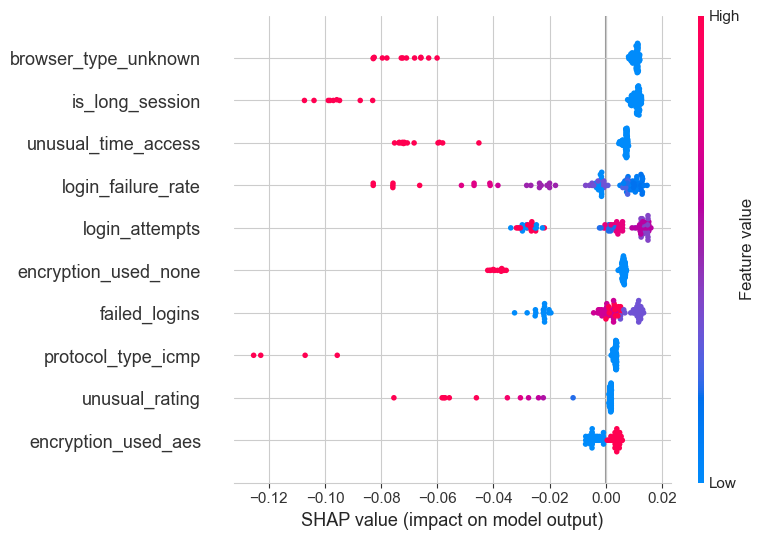

Analyzing sample index: 2


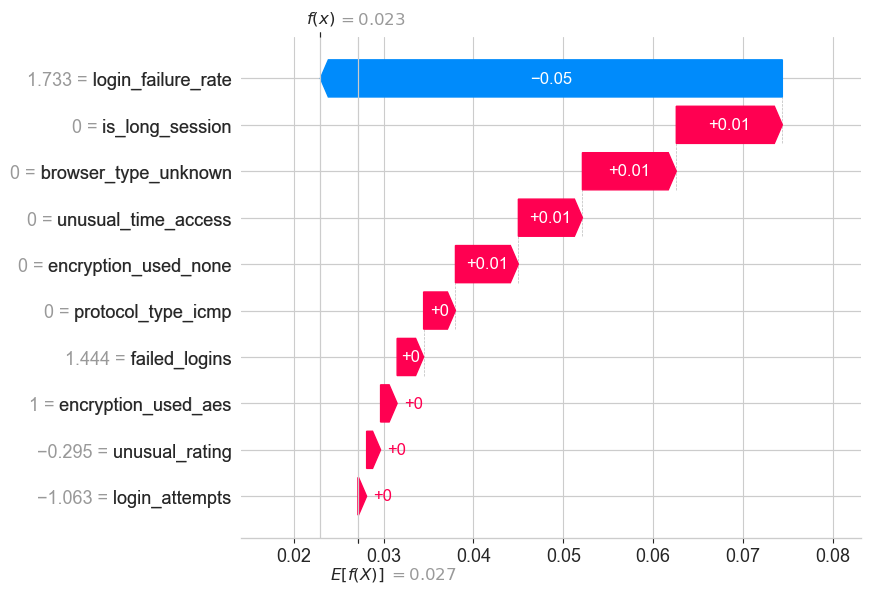

In [62]:
# 6.3 Supervised Model SHAP
import shap

# SHAP for Isolation Forest
shap.initjs()

# Use a sample of the test set for SHAP analysis for performance 
X_sample_unsup = X_test_unsup.sample(100, random_state=42)

# Use the continuous anomaly scores instead of discrete predictions
explainer_if = shap.Explainer(model_if.decision_function, X_train_unsup_normal)

# SHAP values for the sampled test data
shap_values_if = explainer_if(X_sample_unsup)

# Shows features most influence anomaly scores
shap.summary_plot(shap_values_if, X_sample_unsup)

# Find one anomaly instance (predicted attack = 1)
anomaly_index = np.where(np.array(y_pred_converted) == 1)[0][0]  # first predicted attack
print("Analyzing sample index:", anomaly_index)

shap.plots.waterfall(shap_values_if[anomaly_index])

#### 6.3.1 Unsupervised SHAP Analysis:

For computational efficiency SHAP was applied on a test sample of 100:

- The features such as login_failure_rate, protocol_type_icmp and browser_type_unknown had the strongest overall impact on prediction score.   

- Compared to the supervised Gradient Boosting model the unsupervised Isolation Forest is more evenly distributed across multiple features rather than being dominated by one or two strong predictors

- While the supervised Gradient Boosting model did not include the **ip_reputation_score** feature, which SHAP identified as one of the most influential indicators in the unsupervised Isolation Forest model.

- This high-impact feature could've contributed to the unsupervised model’s weaker performance and the unsupervised superior performance. This model could've lacked access to a key feature that strongly correlates with malicious behavior.  



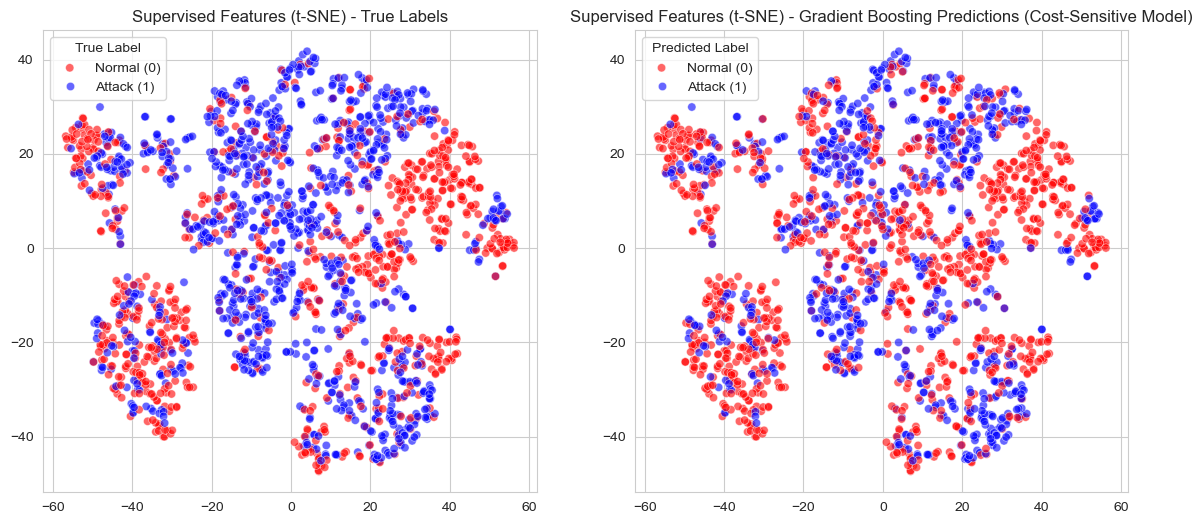

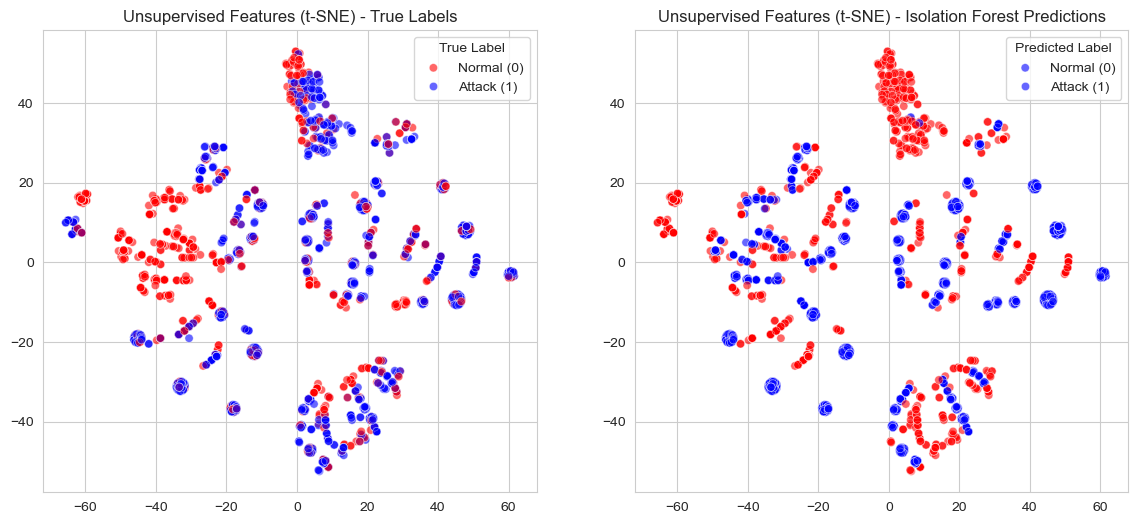

In [ ]:
# 6.4 t-SNE insight of supervised and unsupervised model features 
from sklearn.manifold import TSNE

# t-SNE setup function
def setup_tsne(X, n_components=2, random_state=42):
    return TSNE(n_components=n_components, init='random', learning_rate='auto', random_state=random_state).fit_transform(X)

# Flatten labels/predictions
y_test_flat = np.ravel(y_test) # Test split
y_pred_if_flat = np.ravel(y_pred_converted) # Isolation Forest prediction model from previous cell
y_pred_gb_flat = np.ravel(y_pred_gb_w) # Gradient Boosting Classifier prediction model (Cost-Sensitive Model)

# Perform TSNE
X_test_unsup_tsne = setup_tsne(X_test_unsup)
X_test_sup_tsne = setup_tsne(X_test_sup)

# Plotting setup
def plot_tsne(X_2d, y_true, y_pred, title_true, title_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # True labels
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y_true,
                    palette={0: "blue", 1: "red"}, alpha=0.6, ax=axes[0])
    axes[0].set_title(title_true)
    axes[0].legend(title="True Label", labels=["Normal (0)", "Attack (1)"])

    # Predicted labels
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y_pred,
                    palette={0: "blue", 1: "red"}, alpha=0.6, ax=axes[1])
    axes[1].set_title(title_pred)
    axes[1].legend(title="Predicted Label", labels=["Normal (0)", "Attack (1)"])

    # show plot
    plt.show()


# Plot supervised features (Gradient Boosting Classifier)
plot_tsne(
    X_test_sup_tsne, y_test_flat, y_pred_gb_flat,
    "Supervised Features (t-SNE) - True Labels",
    "Supervised Features (t-SNE) - Gradient Boosting (Cost-Sensitive Model) Predictions"
)

# Plot unsupervised features (Isolation Forest):
plot_tsne(
    X_test_unsup_tsne, y_test_flat, y_pred_if_flat,
    "Unsupervised Features (t-SNE) - True Labels",
    "Unsupervised Features (t-SNE) - Isolation Forest Predictions"
)


#### 6.3.1 t-SNE Insights

Supervised Features (Gradient Boosting Classifier): 

1. Supervised Features (top left) – True Labels:
    - Shows a distinct cluster between Normal (red) and Attack (blue) but overlaping
2. Supervised Features (top right) – Gradient Boosting Predictions:
    - Predictions align very closely with the true labels. The model performed well compared to True lables given it features.

Unsupervised Features (Isolation Forest):
1. Unsupervised Features (bottom left) – True Labels:
    - The Normal (red) and Attack (blue) samples are highly mixed and there is no clear cluster separation.
2. Unsupervised Features (bottom right) – Isolation Forest Predictions:
    - Predictions are scattered similary but not matching the true structure. 
    
    - A noticeable large cluster (top center) is entirely 'normal' and compared to the true lables, the model has treated that entire region as normal traffic. The model could have done this because the features chosen by Laplacian Score could've lacked discriminative power.


# 7. Project Summary

This project focuses on analyzing network session data to detect potential intrusion or attack activities using exploratory data analysis and machine learning techniques.

An initial supervised model was trained to detect anomalies and created a baseline for supervised model.

- A supervised Gradient Boosting Classifier (GBC) was then developed using labeled data. This model became the baseline showing strong accuracy metrics but missing a significant number of true attacks (high False Negatives).

- Cost-sensitive tuning was applied emphasizing Recall to reduce missed detections. The optimized model achieved a substantial drop in False Negatives while maintaining manageable Precision.

Key Findings:

- Unsupervised anomaly detectionwas unsuitable for this intrusion data.Specially missing the high-impact feature **ip_reputation_score** feature

- Cost-sensitive learning significantly improves security performance by prioritizing Recall.

Conclusion:
The final model was tuned so that it minimises asymmetric cost of errors compared to other models and maintains operational practicalily and aligns model performance with real-world security priorities.